In [1]:
# DASK client set

import os
import sys
from dask.distributed import Client
# client = Client(scheduler_file='/proj/kimyy/Dropbox/source/python/all/mpi/scheduler.json', threads_per_worker=2, n_workers=6)
client = Client(scheduler_file='/proj/kimyy/Dropbox/source/python/all/mpi/scheduler.json')
# client = Client(scheduler_file='/proj/kimyy/Dropbox/source/python/all/mpi/scheduler_10.json')  

# add private module path for workers
# client.run(lambda: os.environ.update({'PYTHONPATH': '/proj/kimyy/Dropbox/source/python/all/Modules/CESM2'}))
# def add_path():
#     if '/proj/kimyy/Dropbox/source/python/all/Modules/CESM2' not in sys.path:
#         sys.path.append('/proj/kimyy/Dropbox/source/python/all/Modules/CESM2')

# client.run(add_path)

def setup_module_path():
    module_path = '/proj/kimyy/Dropbox/source/python/all/Modules/CESM2'
    if module_path not in sys.path:
        sys.path.append(module_path)

client.run(setup_module_path)

client

# get path for path changes in Jupyter notebook: File - Open from Path - insert relative_path
notebook_path = os.path.abspath(".")
_, _, relative_path = notebook_path.partition('/all/')
relative_path = '/all/' + relative_path
relative_path

'/all/Model/CESM2/Earth_System_Predictability/DIC'

# Load modules

In [2]:
# load public modules

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import matplotlib.ticker as mticker
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats
from scipy.interpolate import griddata
import cmocean
from cmcrameri import cm
import warnings
warnings.simplefilter(action='ignore')
import pandas as pd
import cftime
import pop_tools
from pprint import pprint
import time
import subprocess
import re as re_mod
import cftime
import datetime
from scipy.stats import ttest_1samp


In [3]:
import xcesm
import gsw

In [4]:
# load private modules

import sys
sys.path.append('/proj/kimyy/Dropbox/source/python/all/Modules/CESM2')
from KYY_CESM2_NWP_preprocessing import CESM2_NWP_config
# import KYY_CESM2_preprocessing
# import importlib
# importlib.reload(KYY_CESM2_preprocessing)

# Variable configuration

In [5]:
# # 1. DIC (Total)
# cfg_var_DIC=CESM2_NWP_config()
# cfg_var_DIC.year_s=1955
# cfg_var_DIC.year_e=2020
# cfg_var_DIC.setvar('DIC')

# # 2. TEMP (Total)
# cfg_var_TEMP=CESM2_NWP_config()
# cfg_var_TEMP.year_s=1955
# cfg_var_TEMP.year_e=2020
# cfg_var_TEMP.setvar('TEMP')

# # 3. SALT (Total)
# cfg_var_SALT=CESM2_NWP_config()
# cfg_var_SALT.year_s=1955
# cfg_var_SALT.year_e=2020
# cfg_var_SALT.setvar('SALT')
cfgs = {}
varlist = ["DIC", "TEMP", "SALT", "FG_CO2", "DIC_ALT_CO2"]
for varname in varlist:
    cfg = CESM2_NWP_config()
    cfg.year_s = 1954
    cfg.year_e = 2020
    cfg.setvar(varname)
    cfgs[varname] = cfg

if cfgs[varname].comp=='ocn':
    ds_grid = pop_tools.get_grid('POP_gx1v7')

# Read dataset (functions)

In [6]:
# define preprocessing function

# exceptcv=['time','lon','lat','lev', 'TAREA', 'TLONG', 'TLAT', 'z_t', 'z_t_2', cfg_var_DIC.var, cfg_var_TEMP.var]
# exceptcv=['time','lon','lat','lev', 'TAREA', 'TLONG', 'TLAT', 'z_t', 'dz', 'z_t_2', cfg_var_DIC.var, cfg_var_TEMP.var]


# exceptcv = [
#     'time', 'lon', 'lat', 'lev', 'TAREA', 'TLONG', 'TLAT', 'z_w', 'z_w_top', 'z_t', 'ULONG', 'ULAT', 'VLONG', 'VLAT'
# ] + [cfg.var for cfg in cfgs.values()]
exceptcv = [
    'time', 'lon', 'lat', 'lev', 'TAREA', 'TLONG', 'TLAT', 'z_t', 'MTD'
] + [cfg.var for cfg in cfgs.values()]



def process_coords_3d(ds, sd, ed, drop=True, except_coord_vars=exceptcv):
    """Preprocessor function to drop all non-dim coords, which slows down concatenation."""
    coord_vars = []
    for v in np.array(ds.coords) :
        if not v in except_coord_vars:
            coord_vars += [v]
    for v in np.array(ds.data_vars) :
        if not v in except_coord_vars:
            coord_vars += [v]

    if drop:
        ds= ds.drop(coord_vars)
        ds= ds.sel(time=slice(sd, ed))
        # ds = ds.isel(z_t=slice(0, 39)) # ~39 layer (1000m)
        # ds = (ds.isel(z_t=slice(1, 39)) * ds.dz).sum(dim='z_t') / ds.dz.sum(dim='z_t')
        return ds
    else:
        return ds.set_coords(coord_vars)



def process_coords_3d_LE(ds, sd, ed, drop=True, except_coord_vars=exceptcv):
    """
    Preprocessor function for CESM POP-style datasets.
    - Normalizes vertical coordinate: if z_t or z_t_2 exists, rename to 'depth'.
    - Replaces its values with z_t_new for consistency.
    - Optionally drops unnecessary coordinate variables for faster concatenation.
    """
    z_t_new = np.array([5.0000000e+00, 1.5000000e+01, 2.5000000e+01, 3.5000000e+01,
       4.5000000e+01, 5.5000000e+01, 6.5000000e+01, 7.5000000e+01,
       8.5000000e+01, 9.5000000e+01, 1.0500000e+02, 1.1500000e+02,
       1.2500000e+02, 1.3500000e+02, 1.4500000e+02, 1.5500000e+02,
       1.6509839e+02, 1.7547903e+02, 1.8629126e+02, 1.9766026e+02,
       2.0971138e+02, 2.2257828e+02, 2.3640883e+02, 2.5137015e+02,
       2.6765421e+02, 2.8548364e+02, 3.0511920e+02, 3.2686798e+02,
       3.5109348e+02, 3.7822760e+02, 4.0878464e+02, 4.4337769e+02,
       4.8273669e+02, 5.2772797e+02, 5.7937286e+02, 6.3886261e+02,
       7.0756329e+02, 7.8700250e+02, 8.7882520e+02, 9.8470581e+02,
       1.1062042e+03, 1.2445669e+03, 1.4004972e+03, 1.5739464e+03,
       1.7640033e+03, 1.9689442e+03, 2.1864565e+03, 2.4139714e+03,
       2.6490012e+03, 2.8893845e+03, 3.1334045e+03, 3.3797935e+03,
       3.6276702e+03, 3.8764519e+03, 4.1257681e+03, 4.3753926e+03,
       4.6251904e+03, 4.8750835e+03, 5.1250278e+03, 5.3750000e+03])
    
    # ------------------------------------------------------
    # 1️⃣ Normalize vertical coordinate name
    # ------------------------------------------------------
    if "z_t_2" in ds.dims:
        ds = ds.rename({"z_t_2": "depth"})
    elif "z_t" in ds.dims:
        ds = ds.rename({"z_t": "depth"})
    else:
        print("[Warning] No vertical coordinate (z_t or z_t_2) found — skipped.")
        return ds

    # Drop any leftover z_t/z_t_2 coordinate variable if it exists
    ds = ds.drop_vars(["z_t", "z_t_2"], errors="ignore")

    # ------------------------------------------------------
    # 2️⃣ Replace coordinate values with z_t_new
    # ------------------------------------------------------
    if "depth" in ds.coords:
        if len(ds["depth"]) == len(z_t_new):
            ds = ds.assign_coords(depth=z_t_new)
        else:
            print(f"[Warning] depth length mismatch: {len(ds['depth'])} vs {len(z_t_new)}")
    else:
        print("[Warning] depth coordinate missing after renaming.")

    # ------------------------------------------------------
    # 3️⃣ Clean up coordinate references inside variable attributes
    # ------------------------------------------------------
    for v in ds.data_vars:
        if "coordinates" in ds[v].attrs:
            ds[v].attrs["coordinates"] = (
                ds[v].attrs["coordinates"]
                .replace("z_t_2", "depth")
                .replace("z_t", "depth")
            )

    # ------------------------------------------------------
    # 4️⃣ Drop unnecessary coordinate variables and slice time
    # ------------------------------------------------------
    coord_vars = []
    for v in np.array(ds.coords):
        if v not in except_coord_vars:
            coord_vars.append(v)
    for v in np.array(ds.data_vars):
        if v not in except_coord_vars:
            coord_vars.append(v)

    if drop:
        ds = ds.drop(coord_vars, errors="ignore")
        ds = ds.sel(time=slice(sd, ed))
    else:
        ds = ds.set_coords(coord_vars)

    return ds

start_date = cftime.DatetimeNoLeap(cfgs[varname].year_s, 2, 1)
end_date = cftime.DatetimeNoLeap(cfgs[varname].year_e+1, 1, 1)


# ds = ds.isel(lev=slice(1, 11))

In [7]:
lat_range = slice(10, 60)
lon_range = slice(110, 190)

# read dataset (regridded variables)

In [8]:
# get ODA regridded file list

import os
import glob

BASE_RGD = "/mnt/lustre/proj/kimyy/tr_sysong/fld/regridded/ODA/NWP/ocn"

vars = varlist
file_list_assm = {}

for var in vars:
    print(f"\n===== Collecting regridded files for {var} =====")

    var_dir = os.path.join(BASE_RGD, var)

    if not os.path.isdir(var_dir):
        print(f"Directory not found: {var_dir}")
        continue

    # Detect ensemble directories automatically
    ens_dirs = sorted(
        [
            d for d in os.listdir(var_dir)
            if os.path.isdir(os.path.join(var_dir, d))
        ]
    )

    print(f"Detected ensembles: {ens_dirs}")

    rgd_file_list = []

    for ens in ens_dirs:
        ens_path = os.path.join(var_dir, ens)

        # Collect all regridded files regardless of time segmentation
        files = sorted(
            glob.glob(os.path.join(ens_path, "regridded_*.nc"))
        )

        # print(f"\n--- Ensemble {ens} ---")
        # print(f"Number of files: {len(files)}")

        # for f in files:
        #     print(f)

        rgd_file_list.append(files)

    file_list_assm[var] = rgd_file_list


===== Collecting regridded files for DIC =====
Detected ensembles: ['en4.2_ba-10p1', 'en4.2_ba-10p2', 'en4.2_ba-10p3', 'en4.2_ba-10p4', 'en4.2_ba-10p5', 'en4.2_ba-20p1', 'en4.2_ba-20p2', 'en4.2_ba-20p3', 'en4.2_ba-20p4', 'en4.2_ba-20p5', 'projdv7.3_ba-10p1', 'projdv7.3_ba-10p2', 'projdv7.3_ba-10p3', 'projdv7.3_ba-10p4', 'projdv7.3_ba-10p5', 'projdv7.3_ba-20p1', 'projdv7.3_ba-20p2', 'projdv7.3_ba-20p3', 'projdv7.3_ba-20p4', 'projdv7.3_ba-20p5']

===== Collecting regridded files for TEMP =====
Detected ensembles: ['en4.2_ba-10p1', 'en4.2_ba-10p2', 'en4.2_ba-10p3', 'en4.2_ba-10p4', 'en4.2_ba-10p5', 'en4.2_ba-20p1', 'en4.2_ba-20p2', 'en4.2_ba-20p3', 'en4.2_ba-20p4', 'en4.2_ba-20p5', 'projdv7.3_ba-10p1', 'projdv7.3_ba-10p2', 'projdv7.3_ba-10p3', 'projdv7.3_ba-10p4', 'projdv7.3_ba-10p5', 'projdv7.3_ba-20p1', 'projdv7.3_ba-20p2', 'projdv7.3_ba-20p3', 'projdv7.3_ba-20p4', 'projdv7.3_ba-20p5']

===== Collecting regridded files for SALT =====
Detected ensembles: ['en4.2_ba-10p1', 'en4.2_ba-10p2

In [9]:
# get ODA regridded file list (MTD only)

BASE_RGD = "/mnt/lustre/proj/kimyy/tr_sysong/fld/regridded/ODA/NWP/ocn"

var = 'MTD'
print(f"\n===== Collecting regridded files for {var} =====")

var_dir = os.path.join(BASE_RGD, var)

# Detect ensemble directories automatically
ens_dirs = sorted(
    [
        d for d in os.listdir(var_dir)
        if os.path.isdir(os.path.join(var_dir, d))
    ]
)

print(f"Detected ensembles: {ens_dirs}")

rgd_file_list = []

for ens in ens_dirs:
    ens_path = os.path.join(var_dir, ens)

    # Collect all regridded files regardless of time segmentation
    files = sorted(
        glob.glob(os.path.join(ens_path, "regridded_*.nc"))
    )
    rgd_file_list.append(files)

file_list_assm[var] = rgd_file_list


===== Collecting regridded files for MTD =====
Detected ensembles: ['en4.2_ba-10p1', 'en4.2_ba-10p2', 'en4.2_ba-10p3', 'en4.2_ba-10p4', 'en4.2_ba-10p5', 'en4.2_ba-20p1', 'en4.2_ba-20p2', 'en4.2_ba-20p3', 'en4.2_ba-20p4', 'en4.2_ba-20p5', 'projdv7.3_ba-10p1', 'projdv7.3_ba-10p2', 'projdv7.3_ba-10p3', 'projdv7.3_ba-10p4', 'projdv7.3_ba-10p5', 'projdv7.3_ba-20p1', 'projdv7.3_ba-20p2', 'projdv7.3_ba-20p3', 'projdv7.3_ba-20p4', 'projdv7.3_ba-20p5']


In [10]:
# get WDA regridded file list (MTD only)

import os
import glob

BASE_RGD = "/mnt/lustre/proj/kimyy/tr_sysong/fld/regridded/WDA/NWP/ocn"

var = "MTD"

print(f"\n===== Collecting WDA regridded files for {var} =====")

var_dir = os.path.join(BASE_RGD, var)

if not os.path.isdir(var_dir):
    raise FileNotFoundError(f"WDA directory not found: {var_dir}")

# WDA: ens 폴더 없음 → 바로 파일 수집
files = sorted(
    glob.glob(os.path.join(var_dir, "regridded_*.nc"))
)

print(f"WDA files found: {len(files)}")

# ODA와 동일 인터페이스 유지 (list of list)
file_list_WDA = {}
file_list_WDA[var] = [files]



===== Collecting WDA regridded files for MTD =====
WDA files found: 14


In [11]:
# get LE regridded file list

import os
import glob
import re
from collections import defaultdict

BASE_RGD = "/mnt/lustre/proj/kimyy/tr_sysong/fld/regridded/LENS2/NWP/ocn"

vars = varlist
file_list_le = {}

for var in vars:
    print(f"\n===== Collecting regridded files for {var} =====")

    var_dir = os.path.join(BASE_RGD, var)

    if not os.path.isdir(var_dir):
        print(f"Directory not found: {var_dir}")
        continue

    ens_dirs = [
        d for d in os.listdir(var_dir)
        if os.path.isdir(os.path.join(var_dir, d))
    ]

    # Group by LE member ID (LE2-xxxx.xxx)
    grouped = defaultdict(list)

    for ens_dir in ens_dirs:
        match = re.search(r"(LE2-[0-9]+\.[0-9]+)", ens_dir)
        if match:
            member_id = match.group(1)
            full_path = os.path.join(var_dir, ens_dir)

            files = glob.glob(
                os.path.join(full_path, "regridded_*.nc")
            )

            grouped[member_id].extend(files)

    # Sort each member's files
    final_file_list = []

    for member in sorted(grouped.keys()):
        files_sorted = sorted(grouped[member])
        # print(f"\n--- Member {member} ---")
        # print(f"Number of files: {len(files_sorted)}")
        # for f in files_sorted:
        #     print(f)

        final_file_list.append(files_sorted)

    file_list_le[var] = final_file_list



===== Collecting regridded files for DIC =====

===== Collecting regridded files for TEMP =====

===== Collecting regridded files for SALT =====

===== Collecting regridded files for FG_CO2 =====

===== Collecting regridded files for DIC_ALT_CO2 =====


In [19]:
# read regridded files

vars = varlist
results = {}

for var in vars:
    print(f"\n===== Processing {var} =====")

    cfg_var = cfgs[var]
    cfg_var.var = var

    # ================= LE =================
    t0 = time.time()
    cfg_var.LE_path_load(cfg_var.var)
    cfg_var.LE_ds_rgd = xr.open_mfdataset(
        file_list_le[var],
        chunks={'time': 12},
        combine='nested',
        concat_dim=[[*cfg_var.LE_ensembles], 'time'],
        parallel=True,
        preprocess=lambda ds: process_coords_3d(ds, start_date, end_date),
        decode_cf=True,
        decode_times=True,
    )
    cfg_var.LE_ds_rgd = cfg_var.LE_ds_rgd.rename({"concat_dim": "ens_LE"})
    cfg_var.LE_ds_rgd = cfg_var.LE_ds_rgd.sortby("time")
    print(f"  LE read: {time.time() - t0:.1f} s")


    # ================= WDA =================
    t0 = time.time()
    cfg_var.WDA_path_load(cfg_var.var)
    cfg_var.WDA_ds = xr.open_mfdataset(
        cfg_var.WDA_file_list[0],
        chunks={'time': 12},
        combine='nested',
        concat_dim=[[*cfg_var.WDA_ensembles], 'time'],
        parallel=True,
        preprocess=lambda ds: process_coords_3d_LE(ds, start_date, end_date),
        decode_cf=True,
        decode_times=True,
    )
    cfg_var.WDA_ds = cfg_var.WDA_ds.rename({"concat_dim": "ens_WDA"})
    new_time = cfg_var.WDA_ds.time - np.array(
        [datetime.timedelta(days=15)] * len(cfg_var.WDA_ds.time)
    )
    if "depth" in cfg_var.WDA_ds.dims:
        cfg_var.WDA_ds = cfg_var.WDA_ds.rename({"depth": "z_t"})
    cfg_var.WDA_ds = cfg_var.WDA_ds.assign_coords(time=new_time)
    print(f"  WDA read: {time.time() - t0:.1f} s")

    # ================= ODA =================
    t0 = time.time()
    cfg_var.ODA_path_load(cfg_var.var)
    cfg_var.ODA_ds_rgd = xr.open_mfdataset(
        file_list_assm[var][10:20],
        chunks={'time': 12},
        combine='nested',
        concat_dim=[[*cfg_var.ODA_ensembles][10:20], 'time'],
        parallel=True,
        preprocess=lambda ds: process_coords_3d(ds, start_date, end_date),
        decode_cf=True,
        decode_times=True,
    )
    cfg_var.ODA_ds_rgd = cfg_var.ODA_ds_rgd.rename({"concat_dim": "ens_ODA"})
    cfg_var.ODA_ds_rgd = cfg_var.ODA_ds_rgd.sortby("time")
    print(f"  ODA read: {time.time() - t0:.1f} s")

    
    cfg_var.WDA_ds_rgd = (
        cfg_var.WDA_ds[var]
        .isel(ens_WDA=0)
        .utils.regrid()
        .sel(lat=lat_range, lon=lon_range)
        .sortby("time")
    )
    print(f"  REGRID WDA: {time.time() - t0:.1f} s")

    if "z_t" in cfg_var.LE_ds_rgd.dims and "z_t" in cfg_var.ODA_ds_rgd.coords:
        cfg_var.LE_ds_rgd = cfg_var.LE_ds_rgd.assign_coords(
            z_t=cfg_var.ODA_ds_rgd.z_t
        )
    
    if "z_t" in cfg_var.WDA_ds_rgd.dims and "z_t" in cfg_var.ODA_ds_rgd.coords:
        cfg_var.WDA_ds_rgd = cfg_var.WDA_ds_rgd.assign_coords(
            z_t=cfg_var.ODA_ds_rgd.z_t
        )
    
    results[var] = cfg_var



===== Processing DIC =====
  LE read: 4.9 s
  WDA read: 1.7 s
  ODA read: 2.7 s
  REGRID WDA: 51.9 s

===== Processing TEMP =====
  LE read: 4.6 s
  WDA read: 1.7 s
  ODA read: 2.7 s
  REGRID WDA: 51.9 s

===== Processing SALT =====
  LE read: 4.5 s
  WDA read: 2.1 s
  ODA read: 2.5 s
  REGRID WDA: 52.2 s

===== Processing FG_CO2 =====
  LE read: 4.1 s
  WDA read: 1.8 s
  ODA read: 2.3 s
  REGRID WDA: 3.4 s

===== Processing DIC_ALT_CO2 =====
  LE read: 4.7 s
  WDA read: 1.6 s
  ODA read: 3.1 s
  REGRID WDA: 52.0 s


In [22]:
import os
import time
import numpy as np
import xarray as xr
import gsw
from datetime import datetime

# ====================================================
# SETTINGS
# ====================================================
BASE_OUTDIR = "/mnt/lustre/proj/kimyy/tr_sysong/fld/sigma0"

lat_range = slice(19, 41)
lon_range = slice(120, 180)
zmax = 500.0  # meters

years = range(1955, 2021)
exps = ["WDA"]

# ====================================================
# SIGMA0 FUNCTION
# ====================================================
def compute_sigma0(temp, salt):

    z = -temp.z_t / 100.0
    lat = temp.lat

    z2d, lat2d = xr.broadcast(z, lat)

    p2d = xr.apply_ufunc(
        gsw.p_from_z,
        z2d,
        lat2d,
        dask="parallelized",
        output_dtypes=[float],
    )

    p = p2d.broadcast_like(temp)

    SA = xr.apply_ufunc(
        gsw.SA_from_SP,
        salt,
        p,
        salt.lon,
        salt.lat,
        dask="parallelized",
        output_dtypes=[float],
    )

    CT = xr.apply_ufunc(
        gsw.CT_from_pt,
        SA,
        temp,
        dask="parallelized",
        output_dtypes=[float],
    )

    sigma0 = xr.apply_ufunc(
        gsw.sigma0,
        SA,
        CT,
        dask="parallelized",
        output_dtypes=[float],
    )

    sigma0.name = "sigma0"
    sigma0.attrs["long_name"] = "Potential density anomaly (sigma0)"
    sigma0.attrs["units"] = "kg m-3"

    return sigma0


# ====================================================
# MAIN LOOP
# ====================================================

t0 = time.time()

for exp in exps:
    print(f"===== {exp} =====")

    temp_all = getattr(results["TEMP"], f"{exp}_ds_rgd")
    salt_all = getattr(results["SALT"], f"{exp}_ds_rgd")

    # temp_all = temp_all.rename({"depth": "z_t"})
    # salt_all = salt_all.rename({"depth": "z_t"})
    
    model_dir = os.path.join(BASE_OUTDIR, exp)
    os.makedirs(model_dir, exist_ok=True)

    print("--- Single member run ---")

    wrote_any = False

    for year in years:

        outfile = os.path.join(
            model_dir,
            f"sigma0_{exp}_{year}.nc"
        )

        if os.path.exists(outfile):
            continue

        zmax_cm = zmax * 100.0

        temp_y = (
            temp_all
            .sel(time=str(year))
            .sel(lat=lat_range, lon=lon_range)
            .sel(z_t=slice(0, zmax_cm))
        )

        salt_y = (
            salt_all
            .sel(time=str(year))
            .sel(lat=lat_range, lon=lon_range)
            .sel(z_t=slice(0, zmax_cm))
        )

        sigma0 = compute_sigma0(temp_y, salt_y)

        sigma0.to_netcdf(
            outfile,
            format="NETCDF4_CLASSIC",
            encoding={"sigma0": {"zlib": True, "complevel": 4}},
        )

        wrote_any = True
        now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        elapsed = time.time() - t0

    if wrote_any:
        print(f"[{now}] saved → {model_dir} | elapsed: {elapsed:.1f} s")


===== WDA =====
--- Single member run ---


In [23]:
# read ODA regridded files (MTD)

var = 'MTD'

cfg = CESM2_NWP_config()
cfg.year_s = 1954
cfg.year_e = 2020
# cfg.setvar(var)
cfgs[var] = cfg

print(f"\n===== Processing {var} =====")

cfg_var = cfgs[var]
cfg_var.var = var

# ================= ODA =================
t0 = time.time()
cfg_var.ODA_ds_rgd = xr.open_mfdataset(
    file_list_assm[var][10:20],
    chunks={'time': 12},
    combine='nested',
    concat_dim=[[*cfgs['TEMP'].ODA_ensembles][10:20], 'time'],
    parallel=True,
    preprocess=lambda ds: process_coords_3d(ds, start_date, end_date),
    decode_cf=True,
    decode_times=True,
)
cfg_var.ODA_ds_rgd = cfg_var.ODA_ds_rgd.rename({"concat_dim": "ens_ODA"})
cfg_var.ODA_ds_rgd = cfg_var.ODA_ds_rgd.sortby("time")
print(f"  ODA read: {time.time() - t0:.1f} s")

results[var] = cfg_var



===== Processing MTD =====
  ODA read: 4.5 s


In [24]:
# read WDA regridded files (MTD)

# ================= WDA MTD =================
import time

t0 = time.time()

cfg_var.WDA_ds_rgd = xr.open_mfdataset(
    file_list_WDA[var][0],   # ← 핵심 수정
    chunks={'time': 12},
    combine='nested',
    concat_dim='time',
    parallel=True,
    preprocess=lambda ds: process_coords_3d(ds, start_date, end_date),
    decode_cf=True,
    decode_times=True,
)

cfg_var.WDA_ds_rgd = cfg_var.WDA_ds_rgd.sortby("time")

print(f"  WDA read: {time.time() - t0:.1f} s")


  WDA read: 0.2 s


In [25]:
# read sigma0 regridded files

import glob
import os
import xarray as xr

SIGMA0_ROOT = "/mnt/lustre/proj/kimyy/tr_sysong/fld/sigma0"

# Container for results["SIGMA0"]
class SigmaContainer:
    pass

results["SIGMA0"] = SigmaContainer()

for exp in ["LE", "WDA", "ODA"]:

    print(f"===== {exp} =====")

    exp_dir = os.path.join(SIGMA0_ROOT, exp)

    # ------------------------------------------------
    # Case 1: Ensemble subdirectories exist (LE, ODA)
    # ------------------------------------------------
    ens_dirs = sorted(
        [d for d in glob.glob(os.path.join(exp_dir, "*"))
         if os.path.isdir(d)]
    )

    if len(ens_dirs) > 0:

        ds_list = []

        for ens_path in ens_dirs:
            ens = os.path.basename(ens_path)

            filelist = sorted(
                glob.glob(os.path.join(
                    ens_path,
                    f"sigma0_{exp}_{ens}_*.nc"
                ))
            )

            if len(filelist) == 0:
                continue

            print(f"{exp} ens {ens}: {len(filelist)} files")

            ds_ens = xr.open_mfdataset(
                filelist,
                combine="by_coords",
                parallel=True,
                chunks={"time": 12},
                decode_cf=True,
                decode_times=True,
            )

            # Add ensemble coordinate
            ds_ens = ds_ens.expand_dims({"ens": [int(ens)]})
            ds_list.append(ds_ens)

        if len(ds_list) == 0:
            continue

        ds_all = xr.concat(ds_list, dim="ens")

        setattr(
            results["SIGMA0"],
            f"{exp}_ds_rgd",
            ds_all["sigma0"]
        )

    # ------------------------------------------------
    # Case 2: Single-member run (WDA)
    # ------------------------------------------------
    else:

        filelist = sorted(
            glob.glob(os.path.join(
                exp_dir,
                f"sigma0_{exp}_*.nc"
            ))
        )

        print(f"{exp}: {len(filelist)} files")

        ds = xr.open_mfdataset(
            filelist,
            combine="by_coords",
            parallel=True,
            chunks={"time": 12},
            decode_cf=True,
            decode_times=True,
        )

        setattr(
            results["SIGMA0"],
            f"{exp}_ds_rgd",
            ds["sigma0"]
        )


===== LE =====
LE ens 0: 66 files
LE ens 1: 66 files
LE ens 10: 66 files
LE ens 11: 66 files
LE ens 12: 66 files
LE ens 13: 66 files
LE ens 14: 66 files
LE ens 15: 66 files
LE ens 16: 66 files
LE ens 17: 66 files
LE ens 18: 66 files
LE ens 19: 66 files
LE ens 2: 66 files
LE ens 20: 66 files
LE ens 21: 66 files
LE ens 22: 66 files
LE ens 23: 66 files
LE ens 24: 66 files
LE ens 25: 66 files
LE ens 26: 66 files
LE ens 27: 66 files
LE ens 28: 66 files
LE ens 29: 66 files
LE ens 3: 66 files
LE ens 30: 66 files
LE ens 31: 66 files
LE ens 32: 66 files
LE ens 33: 66 files
LE ens 34: 66 files
LE ens 35: 66 files
LE ens 36: 66 files
LE ens 37: 66 files
LE ens 38: 66 files
LE ens 39: 66 files
LE ens 4: 66 files
LE ens 40: 66 files
LE ens 41: 66 files
LE ens 42: 66 files
LE ens 43: 66 files
LE ens 44: 66 files
LE ens 45: 66 files
LE ens 46: 66 files
LE ens 47: 66 files
LE ens 48: 66 files
LE ens 49: 66 files
LE ens 5: 66 files
LE ens 6: 66 files
LE ens 7: 66 files
LE ens 8: 66 files
LE ens 9: 66 f

In [26]:
# make nDIC

results["nDIC"] = CESM2_NWP_config()

for key in ["ODA", "LE", "WDA"]:

    dic_obj  = getattr(results["DIC"],  f"{key}_ds_rgd")
    salt_obj = getattr(results["SALT"], f"{key}_ds_rgd")

    # get DataArrays
    dic_da  = dic_obj["DIC"]  if isinstance(dic_obj,  xr.Dataset) else dic_obj
    salt_da = salt_obj["SALT"] if isinstance(salt_obj, xr.Dataset) else salt_obj

    dic_da, salt_da = xr.align(dic_da, salt_da, join="inner")

    ndic_da = dic_da * 35.0 / salt_da
    ndic_da.name = "nDIC"
    ndic_da.attrs["long_name"] = "Salinity-normalized DIC (S=35)"
    ndic_da.attrs["units"] = dic_da.attrs.get("units","")

    setattr(results["nDIC"], f"{key}_ds_rgd", ndic_da.to_dataset())


In [27]:
# make nDIC_ALT_CO2

results["nDIC_ALT_CO2"] = CESM2_NWP_config()

for key in ["ODA", "LE", "WDA"]:

    dic_obj  = getattr(results["DIC_ALT_CO2"],  f"{key}_ds_rgd")
    salt_obj = getattr(results["SALT"], f"{key}_ds_rgd")

    # get DataArrays
    dic_da  = dic_obj["DIC_ALT_CO2"]  if isinstance(dic_obj,  xr.Dataset) else dic_obj
    salt_da = salt_obj["SALT"] if isinstance(salt_obj, xr.Dataset) else salt_obj

    dic_da, salt_da = xr.align(dic_da, salt_da, join="inner")

    ndic_da = dic_da * 35.0 / salt_da
    ndic_da.name = "nDIC_ALT_CO2"
    ndic_da.attrs["long_name"] = "Salinity-normalized DIC_ALT_CO2 (S=35)"
    ndic_da.attrs["units"] = dic_da.attrs.get("units","")

    setattr(results["nDIC_ALT_CO2"], f"{key}_ds_rgd", ndic_da.to_dataset())

In [28]:
# read MLD files

# ============================================================
# Load gridded 3D diagnostics (MLD / nDIC_INV / DIC_INV)
# ODA / LE / WDA unified loader with toggle
# ============================================================

import glob
import os
import xarray as xr

# ------------------------------------------------------------
# USER TOGGLE
# ------------------------------------------------------------
LOAD_EXP = {
    "ODA": True,
    "LE":  True,
    "WDA": True
}

# ------------------------------------------------------------
# container
# ------------------------------------------------------------
class VarContainer:
    pass


# ------------------------------------------------------------
# generic loaders
# ------------------------------------------------------------
def load_ensemble_var(root_dir, varname, exp, ens_dim="ens"):
    """
    root_dir/
        00/
            var_EXP_00_*.nc
        01/
            var_EXP_01_*.nc
        ...
    """

    print(f"===== {varname} {exp} =====")

    ens_dirs = sorted(
        [d for d in glob.glob(os.path.join(root_dir, "*"))
         if os.path.isdir(d)]
    )

    if len(ens_dirs) == 0:
        print("No ensemble directories found.")
        return None

    ds_list = []

    for ens_path in ens_dirs:
        ens = os.path.basename(ens_path)

        filelist = sorted(
            glob.glob(os.path.join(
                ens_path,
                f"{varname}_{exp}_{ens}_*.nc"
            ))
        )

        if len(filelist) == 0:
            continue

        print(f"{varname} {exp} ens {ens}: {len(filelist)} files")

        ds_ens = xr.open_mfdataset(
            filelist,
            combine="by_coords",
            parallel=True,
            chunks={"time": 12},
            decode_cf=True,
            decode_times=True,
        )

        ds_ens = ds_ens.expand_dims({ens_dim: [int(ens)]})
        ds_list.append(ds_ens)

    if len(ds_list) == 0:
        print("No files loaded.")
        return None

    ds_all = xr.concat(ds_list, dim=ens_dim)

    if varname in ds_all:
        return ds_all[varname]
    else:
        return ds_all[list(ds_all.data_vars)[0]]


def load_single_var(root_dir, varname, exp):
    """
    root_dir/
        var_EXP_*.nc
    """
    print(f"===== {varname} {exp} =====")

    filelist = sorted(
        glob.glob(os.path.join(root_dir, f"{varname}_{exp}_*.nc"))
    )

    if len(filelist) == 0:
        print("No files found.")
        return None

    print(f"{varname} {exp}: {len(filelist)} files")

    ds = xr.open_mfdataset(
        filelist,
        combine="by_coords",
        parallel=True,
        chunks={"time": 12},
        decode_cf=True,
        decode_times=True,
    )

    if varname in ds:
        return ds[varname]
    else:
        return ds[list(ds.data_vars)[0]]


# ============================================================
# LOAD MLD (ODA / LE / WDA)
# ============================================================

results["MLD"] = VarContainer()

ROOTS = {
    "ODA": "/mnt/lustre/proj/kimyy/tr_sysong/fld/MLD/ODA",
    "LE":  "/mnt/lustre/proj/kimyy/tr_sysong/fld/MLD/LE",
    "WDA": "/mnt/lustre/proj/kimyy/tr_sysong/fld/MLD/WDA"
}

for EXP, root in ROOTS.items():

    if not LOAD_EXP.get(EXP, False):
        continue

    if EXP in ["ODA", "LE"]:
        ds = load_ensemble_var(
            root,
            varname="MLD",
            exp=EXP,
            ens_dim=f"ens_{EXP}"
        )
    else:
        ds = load_single_var(
            root,
            varname="MLD",
            exp=EXP
        )

    setattr(results["MLD"], f"{EXP}_ds_rgd", ds)

===== MLD ODA =====
MLD ODA ens 10: 66 files
MLD ODA ens 11: 66 files
MLD ODA ens 12: 66 files
MLD ODA ens 13: 66 files
MLD ODA ens 14: 66 files
MLD ODA ens 15: 66 files
MLD ODA ens 16: 66 files
MLD ODA ens 17: 66 files
MLD ODA ens 18: 66 files
MLD ODA ens 19: 66 files
===== MLD LE =====
MLD LE ens 0: 66 files
MLD LE ens 1: 66 files
MLD LE ens 10: 66 files
MLD LE ens 11: 66 files
MLD LE ens 12: 66 files
MLD LE ens 13: 66 files
MLD LE ens 14: 66 files
MLD LE ens 15: 66 files
MLD LE ens 16: 66 files
MLD LE ens 17: 66 files
MLD LE ens 18: 66 files
MLD LE ens 19: 66 files
MLD LE ens 2: 66 files
MLD LE ens 20: 66 files
MLD LE ens 21: 66 files
MLD LE ens 22: 66 files
MLD LE ens 23: 66 files
MLD LE ens 24: 66 files
MLD LE ens 25: 66 files
MLD LE ens 26: 66 files
MLD LE ens 27: 66 files
MLD LE ens 28: 66 files
MLD LE ens 29: 66 files
MLD LE ens 3: 66 files
MLD LE ens 30: 66 files
MLD LE ens 31: 66 files
MLD LE ens 32: 66 files
MLD LE ens 33: 66 files
MLD LE ens 34: 66 files
MLD LE ens 35: 66 f

In [29]:
# ============================================================
# Load DIC / nDIC inventories (full-depth, 300 m, MLD–MTD)
# ODA / LE / WDA unified loader with toggle
# - Supports:
#     1) 3-component inventories (upper/lower/total)
#     2) single-component inventories (e.g., MLD_MTD)
# ============================================================

import glob
import os
import xarray as xr


# ------------------------------------------------------------
# USER TOGGLE
# ------------------------------------------------------------
LOAD_EXP = {
    "ODA": True,
    "LE":  False,
    "WDA": True
}


# ------------------------------------------------------------
# Simple container
# ------------------------------------------------------------
class VarContainer:
    pass


# ------------------------------------------------------------
# General inventory loader (ensemble)
# ------------------------------------------------------------
def load_inventory_components_ens(
    root_dir,
    var_prefix,
    ens_dim="ens",
    suffix="inventory",
    mode="triple",   # "triple" or "single"
):

    ens_dirs = sorted(
        d for d in glob.glob(os.path.join(root_dir, "*"))
        if os.path.isdir(d)
    )

    if mode == "triple":
        comp_names = ["upper", "lower", "total"]
        comp_data = {c: [] for c in comp_names}
    else:
        comp_data = []

    for ens_path in ens_dirs:
        ens = os.path.basename(ens_path)

        filelist = sorted(glob.glob(os.path.join(ens_path, "*.nc")))
        if not filelist:
            continue

        print(f"{var_prefix} ({suffix}) ens {ens}: {len(filelist)} files")

        ds = xr.open_mfdataset(
            filelist,
            combine="by_coords",
            parallel=True,
            chunks={"time": 12},
            decode_cf=True,
            decode_times=True,
        )

        if mode == "triple":
            for comp in ["upper", "lower", "total"]:
                varname = f"{var_prefix}_{comp}_{suffix}"
                if varname in ds:
                    da = ds[varname].expand_dims({ens_dim: [int(ens)]})
                    comp_data[comp].append(da)
        else:
            varname = f"{var_prefix}_{suffix}_inventory"
            if varname in ds:
                da = ds[varname].expand_dims({ens_dim: [int(ens)]})
                comp_data.append(da)

    if mode == "triple":
        out = {}
        for comp in comp_data:
            if comp_data[comp]:
                out[comp] = xr.concat(comp_data[comp], dim=ens_dim)
        return out
    else:
        if comp_data:
            return {"single": xr.concat(comp_data, dim=ens_dim)}
        return {}


# ------------------------------------------------------------
# General inventory loader (single run: WDA)
# ------------------------------------------------------------
def load_inventory_components_single(
    root_dir,
    var_prefix,
    suffix="inventory",
    mode="triple",
):

    filelist = sorted(glob.glob(os.path.join(root_dir, "*.nc")))
    if not filelist:
        return {}

    print(f"{var_prefix} ({suffix}) WDA: {len(filelist)} files")

    ds = xr.open_mfdataset(
        filelist,
        combine="by_coords",
        parallel=True,
        chunks={"time": 12},
        decode_cf=True,
        decode_times=True,
    )

    if mode == "triple":
        comp_data = {}
        for comp in ["upper", "lower", "total"]:
            varname = f"{var_prefix}_{comp}_{suffix}"
            if varname in ds:
                comp_data[comp] = ds[varname]
        return comp_data
    else:
        varname = f"{var_prefix}_{suffix}_inventory"
        if varname in ds:
            return {"single": ds[varname]}
        return {}


# ============================================================
# ROOT MAPS
# ============================================================

ROOT_MAP = {
    "nDIC_INV": {
        "ODA": "/mnt/lustre/proj/kimyy/tr_sysong/fld/nDIC_INV/ODA",
        "LE":  "/mnt/lustre/proj/kimyy/tr_sysong/fld/nDIC_INV/LE",
        "WDA": "/mnt/lustre/proj/kimyy/tr_sysong/fld/nDIC_INV/WDA",
        "prefix": "nDIC",
        "suffix": "inventory",
        "mode": "triple"
    },
    "nDIC_INV_MLD_MTD": {
        "ODA": "/mnt/lustre/proj/kimyy/tr_sysong/fld/nDIC_INV_MLD_MTD/ODA",
        "LE":  "/mnt/lustre/proj/kimyy/tr_sysong/fld/nDIC_INV_MLD_MTD/LE",
        "WDA": "/mnt/lustre/proj/kimyy/tr_sysong/fld/nDIC_INV_MLD_MTD/WDA",
        "prefix": "nDIC",
        "suffix": "MLD_MTD",
        "mode": "single"
    },
    "DIC_INV": {
        "ODA": "/mnt/lustre/proj/kimyy/tr_sysong/fld/DIC_INV/ODA",
        "LE":  "/mnt/lustre/proj/kimyy/tr_sysong/fld/DIC_INV/LE",
        "WDA": "/mnt/lustre/proj/kimyy/tr_sysong/fld/DIC_INV/WDA",
        "prefix": "DIC",
        "suffix": "inventory",
        "mode": "triple"
    },
    "DIC_INV_300m": {
        "ODA": "/mnt/lustre/proj/kimyy/tr_sysong/fld/DIC_INV_300m/ODA",
        "LE":  "/mnt/lustre/proj/kimyy/tr_sysong/fld/DIC_INV_300m/LE",
        "WDA": "/mnt/lustre/proj/kimyy/tr_sysong/fld/DIC_INV_300m/WDA",
        "prefix": "DIC",
        "suffix": "300m",
        "mode": "triple"
    }
}


# ============================================================
# LOAD LOOP
# ============================================================

for key, cfg in ROOT_MAP.items():

    results[key] = VarContainer()

    for EXP in ["ODA", "LE", "WDA"]:

        if not LOAD_EXP.get(EXP, False):
            continue

        root = cfg[EXP]

        if EXP in ["ODA", "LE"]:
            comps = load_inventory_components_ens(
                root,
                var_prefix=cfg["prefix"],
                ens_dim=f"ens_{EXP}",
                suffix=cfg["suffix"],
                mode=cfg["mode"]
            )
        else:
            comps = load_inventory_components_single(
                root,
                var_prefix=cfg["prefix"],
                suffix=cfg["suffix"],
                mode=cfg["mode"]
            )

        if not comps:
            continue

        # attach to container
        if cfg["mode"] == "triple":
            for comp in ["upper", "lower", "total"]:
                if comp in comps:
                    setattr(
                        results[key],
                        f"{EXP}_{comp}",
                        comps[comp]
                    )
        else:
            if "single" in comps:
                setattr(
                    results[key],
                    f"{EXP}_MLD_MTD",
                    comps["single"]
                )

nDIC (inventory) ens 10: 66 files
nDIC (inventory) ens 11: 66 files
nDIC (inventory) ens 12: 66 files
nDIC (inventory) ens 13: 66 files
nDIC (inventory) ens 14: 66 files
nDIC (inventory) ens 15: 66 files
nDIC (inventory) ens 16: 66 files
nDIC (inventory) ens 17: 66 files
nDIC (inventory) ens 18: 66 files
nDIC (inventory) ens 19: 66 files
nDIC (inventory) WDA: 66 files
nDIC (MLD_MTD) ens 10: 66 files
nDIC (MLD_MTD) ens 11: 66 files
nDIC (MLD_MTD) ens 12: 66 files
nDIC (MLD_MTD) ens 13: 66 files
nDIC (MLD_MTD) ens 14: 66 files
nDIC (MLD_MTD) ens 15: 66 files
nDIC (MLD_MTD) ens 16: 66 files
nDIC (MLD_MTD) ens 17: 66 files
nDIC (MLD_MTD) ens 18: 66 files
nDIC (MLD_MTD) ens 19: 66 files
nDIC (MLD_MTD) WDA: 66 files
DIC (inventory) ens 10: 66 files
DIC (inventory) ens 11: 66 files
DIC (inventory) ens 12: 66 files
DIC (inventory) ens 13: 66 files
DIC (inventory) ens 14: 66 files
DIC (inventory) ens 15: 66 files
DIC (inventory) ens 16: 66 files
DIC (inventory) ens 17: 66 files
DIC (inventory) 

# read indices

In [30]:
# read STMWW mask

import numpy  as np
import pandas as pd
import xarray as xr

def to_xarray(data, lat, lon, name='variable', freq='M', ens=None):
    time = pd.date_range("1958-01-01", "2020-12-31", freq=freq)
    depth = np.array([5.0000000e+00, 1.5000000e+01, 2.5000000e+01, 3.5000000e+01,
       4.5000000e+01, 5.5000000e+01, 6.5000000e+01, 7.5000000e+01,
       8.5000000e+01, 9.5000000e+01, 1.0500000e+02, 1.1500000e+02,
       1.2500000e+02, 1.3500000e+02, 1.4500000e+02, 1.5500000e+02,
       1.6509839e+02, 1.7547903e+02, 1.8629126e+02, 1.9766026e+02,
       2.0971138e+02, 2.2257828e+02, 2.3640883e+02, 2.5137015e+02,
       2.6765421e+02, 2.8548364e+02, 3.0511920e+02, 3.2686798e+02,
       3.5109348e+02, 3.7822760e+02, 4.0878464e+02, 4.4337769e+02,
       4.8273669e+02, 5.2772797e+02, 5.7937286e+02, 6.3886261e+02,
       7.0756329e+02, 7.8700250e+02, 8.7882520e+02, 9.8470581e+02,
       1.1062042e+03, 1.2445669e+03, 1.4004972e+03, 1.5739464e+03,
       1.7640033e+03, 1.9689442e+03, 2.1864565e+03, 2.4139714e+03,
       2.6490012e+03, 2.8893845e+03, 3.1334045e+03, 3.3797935e+03,
       3.6276702e+03, 3.8764519e+03, 4.1257681e+03, 4.3753926e+03,
       4.6251904e+03, 4.8750835e+03, 5.1250278e+03, 5.3750000e+03])

    if ens is None:
        dims = ['time', 'depth', 'lat', 'lon']
        coords = {'time': time, 'depth': depth, 'lat': lat, 'lon': lon}
    else:
        ens = np.asarray(ens)
        dims = ['ens', 'time', 'depth', 'lat', 'lon']
        coords = {'ens': ens, 'time': time, 'depth': depth, 'lat': lat, 'lon': lon}
    da = xr.DataArray(data, name=name, dims=dims, coords=coords)
    return da

indir = '/mnt/lustre/proj/kimyy/tr_sysong/'
fyear = '1958'; eyear = '2017'; lat = np.arange(10,60.1,1); lon = np.arange(110,190.1,1)

data = np.load(indir+'/NPSTMW_STMWW_16to20.npz')
OBS_STMWW = to_xarray(data['OBS_STMWW'], lat, lon, name='OBS_STMWW').sel(time=slice(fyear,eyear))
ODA_STMWW = to_xarray(data['ODA_STMWW'], lat, lon, name='ODA_STMWW', ens=np.arange(1,10.1,1)).sel(time=slice(fyear,eyear))
WDA_STMWW = to_xarray(data['WDA_STMWW'], lat, lon, name='WDA_STMWW').sel(time=slice(fyear,eyear))
ADA_STMWW = to_xarray(data['ADA_STMWW'], lat, lon, name='ADA_STMWW', ens=np.arange(1,10.1,1)).sel(time=slice(fyear,eyear))
LE2_STMWW = to_xarray(data['LE2_STMWW'], lat, lon, name='LE2_STMWW', ens=np.arange(1,50.1,1)).sel(time=slice(fyear,eyear))

In [31]:
# OBS_STMWW_rgd = OBS_STMWW.isel(time=slice(24,720)).isel(lon=slice(0,70)).isel(depth=slice(0,39)).isel(ens=5)
OBS_STMWW_rgd = OBS_STMWW.isel(lon=slice(0,70))
OBS_STMWW_rgd = OBS_STMWW_rgd.rename({"depth": "z_t"})
OBS_STMWW_rgd = OBS_STMWW_rgd.assign_coords(z_t = cfgs['DIC'].ODA_ds_rgd.z_t)
OBS_STMWW_rgd = OBS_STMWW_rgd.assign_coords(time = cfgs['DIC'].ODA_ds_rgd.time.sel(time=slice("1958-01-01", "2017-12-31")))


In [32]:

# ODA_STMWW_rgd = ODA_STMWW.isel(time=slice(24,720)).isel(lon=slice(0,70)).isel(depth=slice(0,39)).isel(ens=5)
ODA_STMWW_rgd = ODA_STMWW.isel(lon=slice(0,70)).isel(ens=5)
ODA_STMWW_rgd = ODA_STMWW_rgd.rename({"depth": "z_t"})
ODA_STMWW_rgd = ODA_STMWW_rgd.assign_coords(z_t = cfgs['DIC'].ODA_ds_rgd.z_t)
ODA_STMWW_rgd = ODA_STMWW_rgd.assign_coords(time = cfgs['DIC'].ODA_ds_rgd.time.sel(time=slice("1958-01-01", "2017-12-31")))

# WDA_STMWW_rgd = WDA_STMWW.isel(time=slice(24,720)).isel(lon=slice(0,70)).isel(depth=slice(0,39))
WDA_STMWW_rgd = WDA_STMWW.isel(lon=slice(0,70))
WDA_STMWW_rgd = WDA_STMWW_rgd.rename({"depth": "z_t"})
WDA_STMWW_rgd = WDA_STMWW_rgd.assign_coords(z_t = cfgs['DIC'].ODA_ds_rgd.z_t)
WDA_STMWW_rgd = WDA_STMWW_rgd.assign_coords(time = cfgs['DIC'].ODA_ds_rgd.time.sel(time=slice("1958-01-01", "2017-12-31")))

# ADA_STMWW_rgd = ADA_STMWW.isel(time=slice(24,720)).isel(lon=slice(0,70)).isel(depth=slice(0,39)).isel(ens=5)
ADA_STMWW_rgd = ADA_STMWW.isel(lon=slice(0,70)).isel(ens=5)
ADA_STMWW_rgd = ADA_STMWW_rgd.rename({"depth": "z_t"})
ADA_STMWW_rgd = ADA_STMWW_rgd.assign_coords(z_t = cfgs['DIC'].ODA_ds_rgd.z_t)
ADA_STMWW_rgd = ADA_STMWW_rgd.assign_coords(time = cfgs['DIC'].ODA_ds_rgd.time.sel(time=slice("1958-01-01", "2017-12-31")))

LE_STMWW_rgd = LE2_STMWW.isel(lon=slice(0,70)).isel(ens=5)
LE_STMWW_rgd = LE_STMWW_rgd.rename({"depth": "z_t"})
LE_STMWW_rgd = LE_STMWW_rgd.assign_coords(z_t = cfgs['DIC'].ODA_ds_rgd.z_t)
LE_STMWW_rgd = LE_STMWW_rgd.assign_coords(time = cfgs['DIC'].ODA_ds_rgd.time.sel(time=slice("1958-01-01", "2017-12-31")))

In [33]:
STMV = xr.open_mfdataset('/mnt/lustre/proj/kimyy/tr_sysong/STMWV_1958to2017.nc')

In [34]:
KE_SSH = xr.open_mfdataset('/mnt/lustre/proj/kimyy/tr_sysong/AVISO_KE_SSH_1993to2022.nc')

# read observations

In [35]:
import xarray as xr
import numpy as np
import glob

# ============================================================
# Settings
# ============================================================
PROJD_DIR = "/mnt/lustre/proj/kimyy/tr_sysong/OBS/ProjD_v7.3/NWP"
FILE_PATTERN = f"{PROJD_DIR}/NWP_toso-proj7.*.nc"

# ============================================================
# 1) Load monthly ProjD files (1955–2022)
# ============================================================
files = sorted(glob.glob(FILE_PATTERN))
print(f"Number of files found: {len(files)}")

ds = xr.open_mfdataset(
    files,
    combine="by_coords",
    parallel=True,
    decode_times=False  
)

# ============================================================
# 2) Rename and clean coordinates
# ============================================================
# POP-style 2D lat/lon → coordinates
ds = ds.rename({
    "TLAT": "lat",
    "TLONG": "lon"
})

# Attach lat/lon as coordinates
ds = ds.set_coords(["lat", "lon"])

# Convert depth from cm to m (positive downward → negative upward if desired)
ds = ds.assign_coords(z_t = ds.z_t / 100.0)
ds["z_t"].attrs["units"] = "m"

# ============================================================
# 3) Extract TEMP and SALT
# ============================================================
temp = ds["TEMP"]
salt = ds["SALT"]

# Mask fill values (xarray usually handles this, but being explicit is safer)
temp = temp.where(np.isfinite(temp))
salt = salt.where(np.isfinite(salt))

# ============================================================
# 4) Compute sigma0
# ============================================================
# Use gsw (TEOS-10). Assumes gsw is available.
import gsw

def compute_sigma0(temp, salt, z):
    """
    Compute sigma0 from TEMP and SALT.

    TEMP: potential temperature [degC]
    SALT: practical salinity [g/kg ~ psu]
    z   : depth [m], positive downward
    """
    # Pressure from depth (z must be positive downward)
    p = gsw.p_from_z(-z, lat=0.0)

    # Broadcast pressure to full 4D shape
    p4d = xr.DataArray(
        p,
        dims=["z_t"],
        coords={"z_t": z}
    )

    # Absolute Salinity and Conservative Temperature
    SA = gsw.SA_from_SP(salt, p4d, 0.0, 0.0)
    CT = gsw.CT_from_pt(SA, temp)

    # Sigma0
    sigma0 = gsw.sigma0(SA, CT)

    return sigma0

sigma0 = compute_sigma0(temp, salt, ds.z_t)
sigma0.name = "SIGMA0"
sigma0.attrs["long_name"] = "Potential density anomaly (sigma0)"
sigma0.attrs["units"] = "kg m-3"

# ============================================================
# 5) Store in results_projd dictionary
# ============================================================
results_projd = {}

results_projd["TEMP"]   = temp
results_projd["SALT"]   = salt
results_projd["SIGMA0"] = sigma0

# Optional: keep a Dataset version as well
results_projd["ds"] = xr.Dataset(
    {
        "TEMP": temp,
        "SALT": salt,
        "SIGMA0": sigma0,
    }
)

print("results_projd contains:", list(results_projd.keys()))


Number of files found: 816
results_projd contains: ['TEMP', 'SALT', 'SIGMA0', 'ds']


In [36]:
# ============================================================
# Regrid ProjD variables (lon/lat → TLONG/TLAT → CESM2 rgd)
# ============================================================

results_projd_rgd = {}

VARS_TO_REGRID = ["SIGMA0"]   # extend if needed

for var in VARS_TO_REGRID:
    print(f"Regridding ProjD variable: {var}")

    da = results_projd[var]

    # --------------------------------------------------------
    # 1) Rename 2D lon/lat to POP-style TLONG/TLAT
    #    (required for xCESM utils.regrid)
    # --------------------------------------------------------
    da = da.rename({
        "lon": "TLONG",
        "lat": "TLAT",
    })

    # --------------------------------------------------------
    # 2) Regrid using xCESM accessor (same as model workflow)
    # --------------------------------------------------------
    da_rgd = (
        da
        .utils.regrid()                 # → CESM2 1x1 lat-lon grid
        .sel(lat=lat_range, lon=lon_range)
        .sortby("time")
    )

    # --------------------------------------------------------
    # 3) Metadata
    # --------------------------------------------------------
    da_rgd.name = var
    da_rgd.attrs["source"] = "POP2 ProjD"
    da_rgd.attrs["regridded_to"] = "CESM2 1x1 lat-lon"
    da_rgd.attrs["regridding_method"] = "xcesm.utils.regrid"

    results_projd_rgd[var] = da_rgd

print("✅ ProjD regridding complete: results_projd_rgd ready")


Regridding ProjD variable: SIGMA0
✅ ProjD regridding complete: results_projd_rgd ready


In [37]:
results_projd_rgd["SIGMA0"] = results_projd_rgd["SIGMA0"].assign_coords(
    z_t=results_projd_rgd["SIGMA0"].z_t * 100.0
)

# (선택) metadata 정리
results_projd_rgd["SIGMA0"].z_t.attrs["units"] = "cm"
results_projd_rgd["SIGMA0"].z_t.attrs["long_name"] = "depth from surface to midpoint of layer"

In [38]:
import numpy as np
import xarray as xr

# Reference time axis from model (monthly, noleap)
time_ref = results["SIGMA0"].LE_ds_rgd.time

# Sanity check
print("Model time range:", time_ref.values[0], "→", time_ref.values[-1])
print("OBS time length:", results_projd_rgd["SIGMA0"].sizes["time"])

# Trim to common length (defensive)
ntime = min(
    results_projd_rgd["SIGMA0"].sizes["time"],
    time_ref.size
)

# Assign model-style time to OBS
results_projd_rgd["SIGMA0"] = (
    results_projd_rgd["SIGMA0"]
    .isel(time=slice(0, ntime))
    .assign_coords(time=time_ref.isel(time=slice(0, ntime)))
)


Model time range: 1955-01-17 00:00:00 → 2020-12-17 00:00:00
OBS time length: 816


In [39]:
# read GLODAP data

import xarray as xr
import pandas as pd

# ============================================================
# USER SETTINGS
# ============================================================
GLODAP_NC = "/mnt/lustre/proj/kimyy/tr_sysong/OBS/GLODAP/NWP_GLODAP_v2_3_1deg_monthly.nc"

lat_range = slice(20, 40)
lon_range = slice(120, 180)
z_range   = slice(0, 500)   # model-consistent depth range

# ============================================================
# 1) Load gridded GLODAP
# ============================================================
ds_obs = xr.open_dataset(GLODAP_NC)

# ============================================================
# 2) Rename variables to match model naming
# ============================================================
ds_obs = ds_obs.rename({
    "G2temperature": "TEMP",
    "G2salinity":    "SALT",
    "G2sigma0":      "SIGMA0",
    "G2tco2":        "DIC",
    "G2talk":        "ALK",
})

# ============================================================
# 3) ym → time coordinate (monthly)
# ============================================================
ds_obs = (
    ds_obs
    .assign_coords(
        time=("ym", pd.to_datetime(ds_obs.ym.astype(str), format="%Y%m"))
    )
    .swap_dims({"ym": "time"})
    .drop_vars("ym")
)

# ============================================================
# 4) Spatial + depth subsetting (model-consistent)
# ============================================================
ds_obs = ds_obs.sel(
    lat=lat_range,
    lon=lon_range,
    z_t=z_range
)

# ============================================================
# 5) Final cleanup (sort, metadata)
# ============================================================
ds_obs = ds_obs.sortby("time")

ds_obs["z_t"].attrs["units"] = "m"
ds_obs["lat"].attrs["units"] = "degrees_north"
ds_obs["lon"].attrs["units"] = "degrees_east"

# ============================================================
# 6) Sanity checks
# ============================================================
print(ds_obs)
print("Time range:", ds_obs.time.min().item(), "→", ds_obs.time.max().item())
print("DIC NaN fraction:", ds_obs.DIC.isnull().mean().item())

# ============================================================
# ds_obs is now directly comparable to model output
# dims: time × z_t × lat × lon
# variables: TEMP, SALT, SIGMA0, DIC, ALK
# ============================================================


<xarray.Dataset> Size: 465MB
Dimensions:      (time: 280, z_t: 18, lat: 21, lon: 61)
Coordinates:
  * z_t          (z_t) float64 144B 5.0 15.0 25.0 35.0 ... 310.0 380.0 460.0
  * lat          (lat) int64 168B 20 21 22 23 24 25 26 ... 34 35 36 37 38 39 40
  * lon          (lon) int64 488B 120 121 122 123 124 ... 176 177 178 179 180
  * time         (time) datetime64[ns] 2kB 1973-10-01 1973-11-01 ... 2020-11-01
Data variables:
    TEMP         (time, z_t, lat, lon) float64 52MB ...
    SALT         (time, z_t, lat, lon) float64 52MB ...
    SIGMA0       (time, z_t, lat, lon) float64 52MB ...
    G2oxygen     (time, z_t, lat, lon) float64 52MB ...
    G2nitrate    (time, z_t, lat, lon) float64 52MB ...
    G2phosphate  (time, z_t, lat, lon) float64 52MB ...
    G2silicate   (time, z_t, lat, lon) float64 52MB ...
    DIC          (time, z_t, lat, lon) float64 52MB ...
    ALK          (time, z_t, lat, lon) float64 52MB ...
Time range: 118281600000000000 → 1604188800000000000
DIC NaN fracti

In [40]:
# ============================================================
# Add nDIC to ds_obs
# ============================================================

dic = ds_obs["DIC"]
salt = ds_obs["SALT"]

# align just in case (safe)
dic, salt = xr.align(dic, salt, join="inner")

ds_obs["nDIC"] = dic * 35.0 / salt

ds_obs["nDIC"].attrs["long_name"] = "Salinity-normalized DIC (S=35)"
ds_obs["nDIC"].attrs["units"] = dic.attrs.get("units","")


In [41]:
# read PDO

import numpy as np
import pandas as pd
import xarray as xr

PDO_FILE = "/mnt/lustre/proj/kimyy/Observation/ERSST/ersst.v5.pdo.dat"

# ------------------------------------------------------------
# read file (skip header)
# ------------------------------------------------------------
years = []
vals  = []

with open(PDO_FILE, "r") as f:
    lines = f.readlines()

for line in lines:
    line = line.strip()

    # skip header lines
    if (not line) or ("Year" in line) or ("PDO" in line):
        continue

    parts = line.split()

    # year + 12 months expected
    if len(parts) != 13:
        continue

    y = int(parts[0])
    monthly = [float(v) for v in parts[1:]]

    years.append(y)
    vals.append(monthly)

years = np.array(years)
vals  = np.array(vals)   # shape (nyear, 12)

# ------------------------------------------------------------
# flatten to monthly time series
# ------------------------------------------------------------
pdo_list = []
time_list = []

for yi, y in enumerate(years):
    for mi in range(12):
        time_list.append(np.datetime64(f"{y}-{mi+1:02d}-01"))
        pdo_list.append(vals[yi, mi])

pdo = xr.DataArray(
    np.array(pdo_list),
    coords={"time": np.array(time_list)},
    dims="time",
    name="PDO"
)

# ensure sorted & load
pdo = pdo.sortby("time").load()

pdo


<xarray.DataArray 'PDO' (time: 2076)> Size: 17kB
array([ 0.11, -0.24, -0.4 , ..., 99.99, 99.99, 99.99])
Coordinates:
  * time     (time) datetime64[s] 17kB 1854-01-01 1854-02-01 ... 2026-12-01

In [42]:
# ============================================================
# HELPERS
# ============================================================

def to_month_start(da):
    da = da.copy()
    da["time"] = da.time.astype("datetime64[M]").astype("datetime64[ns]")
    return da

def annual_mean_func(da):
    da = da.groupby("time.year").mean("time")
    da = da.assign_coords(
        time=("year",[np.datetime64(f"{y}-07-01") for y in da.year.values])
    ).swap_dims({"year":"time"}).drop_vars("year")
    return da

def detrend_nan_safe(da):
    y = da.values.astype(float)
    ok = np.isfinite(y)
    y_dt = np.full_like(y,np.nan)
    if ok.sum()>2 and np.nanstd(y[ok])>1e-12:
        y_dt[ok] = detrend(y[ok],type="linear")
    return da.copy(data=y_dt)

def corr_func(obs,mod):
    o,m = xr.align(obs,mod,join="inner")
    ok = np.isfinite(o.values)&np.isfinite(m.values)
    if ok.sum()<10:
        return np.nan
    return np.corrcoef(o.values[ok],m.values[ok])[0,1]

def get_ens_dim(da):
    return next((d for d in da.dims if d.startswith("ens")), None)


# density_contrained timeseries

In [43]:


SIG_OBS_MIN, SIG_OBS_MAX = 25.0, 25.4
# SIG_MOD_MIN, SIG_MOD_MAX = 24.22, 24.73
SIG_MOD_MIN, SIG_MOD_MAX = 24.40, 24.80
SIG_MOD_MIN_WDA, SIG_MOD_MAX_WDA = 24.20, 24.60

LAT_MIN, LAT_MAX = 20, 30
LON_MIN, LON_MAX = 136, 138

T0_FULL = "1955-01-01"
T0_OBS  = "1990-01-01"
T1      = "2020-12-31"

ke_obs = KE_SSH
STMW_raw = STMV.PD7_STMWV
KE_raw   = ke_obs.AVISO_KE_SSH

STMW_index = (STMW_raw - STMW_raw.mean("time")) / STMW_raw.std("time")
KE_index   = (KE_raw   - KE_raw.mean("time"))   / KE_raw.std("time")

STMW_index_ann = STMW_index.resample(time="YS").mean()
stmw_obs = STMW_index_ann.sel(time=slice(T0_OBS, T1))

thr = 0.5
years = stmw_obs.time.dt.year.values.astype(int)
vals  = stmw_obs.values

high_years = years[vals >  thr]
low_years  = years[vals < -thr]

def stmw_colors(values, thr=0.5):
    cols = []
    for v in values:
        if v >  thr:
            cols.append("#CC79A7")
        elif v < -thr:
            cols.append("#009E73")
        else:
            cols.append("0.7")
    return cols

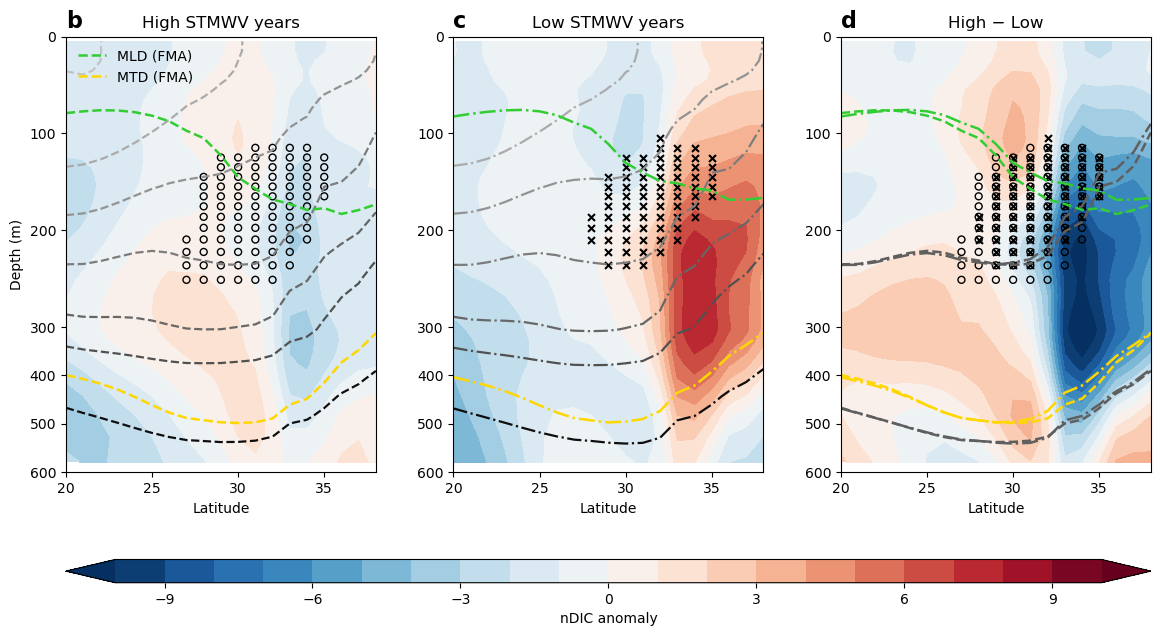

In [44]:
# ============================================================
# FIGURE: (a) nDIC time series + (b–d) composite sections
# ZONAL MEAN 135–170E
# + MLD (green dashed) + MTD (gold dashed)
# + nDIC grayscale contours (absolute field) like your old plot
# compressed depth axis (300–600 → 1/2)
# 135 ~ 170E average version
# ============================================================

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def to_year_start(da):
    years = da.time.dt.year.values
    new_time = np.array([np.datetime64(f"{y}-01-01") for y in years])
    return da.assign_coords(time=new_time)

def depth_compress(z):
    z = np.asarray(z)
    zc = z.copy()
    mask = z > 300
    zc[mask] = 300 + (z[mask] - 300) / 2.0
    return zc

# ============================================================
# ---- COMPOSITE DATA (b–d)  ★ 135–170E
# ============================================================
LON_SL = slice(135,170)
LAT_SL = slice(20,40)
Z_SL   = slice(0,60000)

high_sel = np.array(high_years, dtype=int)
low_sel  = np.array(low_years,  dtype=int)

# ---- nDIC (absolute field + anomalies)
ndic = results["nDIC"].ODA_ds_rgd["nDIC"]
ens_dim = next((d for d in ndic.dims if d.startswith("ens")), None)
if ens_dim:
    ndic = ndic.mean(ens_dim)

ndic = ndic.sel(lon=LON_SL, lat=LAT_SL, z_t=Z_SL).mean("lon")

ndic_ann = ndic.groupby("time.year").mean("time")
ndic_ann = ndic_ann.rename({"year":"time"})
ndic_ann["time"] = np.array([np.datetime64(f"{int(y)}-07-01") for y in ndic_ann.time.values])

# climatology for anomaly shading (keep as you had: 1990–2020)
clim_mask = (ndic_ann.time.dt.year>=1990) & (ndic_ann.time.dt.year<=2020)
ndic_clim = ndic_ann.sel(time=clim_mask).mean("time")

# composites (absolute)
ndic_high = ndic_ann.sel(time=np.isin(ndic_ann.time.dt.year,high_sel)).mean("time")
ndic_low  = ndic_ann.sel(time=np.isin(ndic_ann.time.dt.year,low_sel)).mean("time")

# anomalies (shading)
ndic_high_anom = ndic_high - ndic_clim
ndic_low_anom  = ndic_low  - ndic_clim
ndic_diff      = ndic_high - ndic_low

# ---- grayscale contour levels (same spirit as your old plot)
CONTOUR_LEVELS = [2000, 2040, 2080, 2120, 2160, 2200, 2300]
norm = mpl.colors.Normalize(vmin=min(CONTOUR_LEVELS), vmax=max(CONTOUR_LEVELS))
cmap = mpl.cm.Greys
cont_colors = [cmap(0.35 + 0.6*norm(lv)) for lv in CONTOUR_LEVELS]

# ---- MLD (FMA mean)
MLD = results["MLD"].ODA_ds_rgd
MLD = MLD["MLD"] if isinstance(MLD,xr.Dataset) else MLD
ens_dim = next((d for d in MLD.dims if d.startswith("ens")),None)
if ens_dim:
    MLD = MLD.mean(ens_dim)

MLD = MLD.sel(lon=LON_SL, lat=LAT_SL).mean("lon")/100
MLD = MLD.where(MLD.time.dt.month.isin([2,3,4]), drop=True)
MLD_ann = MLD.groupby("time.year").mean("time")

MLD_high = MLD_ann.sel(year=np.isin(MLD_ann.year,high_sel)).mean("year")
MLD_low  = MLD_ann.sel(year=np.isin(MLD_ann.year,low_sel)).mean("year")

# ---- MTD (FMA mean)
MTD = results["MTD"].ODA_ds_rgd
MTD = MTD["MTD"] if isinstance(MTD,xr.Dataset) else MTD
ens_dim = next((d for d in MTD.dims if d.startswith("ens")),None)
if ens_dim:
    MTD = MTD.mean(ens_dim)

MTD = MTD.sel(lon=LON_SL, lat=LAT_SL).mean("lon")/100
MTD = MTD.where(MTD.time.dt.month.isin([2,3,4]), drop=True)
MTD_ann = MTD.groupby("time.year").mean("time")

MTD_high = MTD_ann.sel(year=np.isin(MTD_ann.year,high_sel)).mean("year")
MTD_low  = MTD_ann.sel(year=np.isin(MTD_ann.year,low_sel)).mean("year")

# ---- STMW fraction markers
stmw = (
    ODA_STMWW_rgd
    .sel(lon=LON_SL, lat=LAT_SL, z_t=Z_SL)
    .mean("lon")
)

years_cf = np.array([t.year for t in stmw.time.values],dtype=int)
year_coord = xr.DataArray(years_cf,dims="time")

stmw_frac = ((stmw>0).groupby(year_coord).mean("time").rename({"group":"year"}))

THRESH=0.8
high_exist = np.intersect1d(high_sel,stmw_frac.year.values)
low_exist  = np.intersect1d(low_sel, stmw_frac.year.values)

stmw_high = stmw_frac.sel(year=high_exist).mean("year")>=THRESH
stmw_low  = stmw_frac.sel(year=low_exist).mean("year")>=THRESH

z_h_idx, lat_h_idx = np.where(stmw_high.values)
z_l_idx, lat_l_idx = np.where(stmw_low.values)

lat_h = stmw_high.lat.values[lat_h_idx]
z_h   = stmw_high.z_t.values[z_h_idx]/100
lat_l = stmw_low.lat.values[lat_l_idx]
z_l   = stmw_low.z_t.values[z_l_idx]/100

# ============================================================
# ---- FIGURE
# ============================================================
fig = plt.figure(figsize=(14,12))
gs = fig.add_gridspec(
    3,3,
    height_ratios=[1,1.5,0.08],
    hspace=0.35,wspace=0.25
)

# # ---- panel a (RESTORED like reference)
# ax = fig.add_subplot(gs[0, :])

# # OBS + models
# ax.scatter(
#     DATA["OBS_DT"].time, DATA["OBS_DT"],
#     s=35, color=OBS_COLOR, label="OBS"
# )

# for m in MODELS:
#     mean = DATA["MOD_DT"][m].sel(time=slice(T0_OBS, T1))
#     std  = DATA["SPREAD"][m]

#     ax.plot(mean.time, mean, color=COLORS[m], lw=2, label=m)

#     if std is not None:
#         std = std.sel(time=slice(T0_OBS, T1))
#         mean, std = xr.align(mean, std)
#         ax.fill_between(mean.time, mean-std, mean+std,
#                         color=COLORS[m], alpha=0.25)

# ax.set_xlim(np.datetime64(f"{T0_OBS[:4]}-01-01"),
#             np.datetime64(f"{T1[:4]}-12-31"))
# ax.set_ylim(-50, 40)
# ax.set_yticks([-20, 0, 20, 40])
# ax.set_ylabel("nDIC anomaly")
# ax.set_title("Annual nDIC (detrended)")

# ax.text(0, 1.02, "a", transform=ax.transAxes,
#         fontsize=16, fontweight="bold")

# # correlation text box (reference style)
# txt = "Models vs OBS nDIC\n" + "\n".join(
#     [f"{m}: r={R[m][0]:.2f}±{R[m][1]:.2f}" for m in MODELS]
# )
# ax.text(0.97, 0.97, txt, transform=ax.transAxes,
#         ha="right", va="top")

# # twin axis: bars + KE line + threshold lines
# ax2 = ax.twinx()

# bar_colors = stmw_colors(stmw_obs.values, thr)
# ax2.bar(
#     stmw_obs.time.values, stmw_obs.values,
#     width=np.timedelta64(365, "D"),
#     color=bar_colors
# )

# ax2.plot(
#     stmw_obs.time.values, ke_obs_ann.values,
#     color="brown", lw=1.8, marker="D", ms=4
# )

# ax2.axhline(thr,  color="0.6", lw=1, ls=":")
# ax2.axhline(-thr, color="0.6", lw=1, ls=":")
# ax2.set_ylim(-2.5, 10)
# ax2.set_yticks([-2, 0, 2])
# ax2.set_ylabel("Normalized STMWV and KE indices")

# # IMPORTANT: keep main axis above twin axis so legends/text don't get hidden
# ax2.set_zorder(0)
# ax.set_zorder(1)
# ax.patch.set_alpha(0)

# # legends (restore BOTH legends)
# leg1 = ax.legend(loc="upper left", bbox_to_anchor=(0.02, 0.98))

# handles2 = [
#     Patch(facecolor="#CC79A7", label="NSTMWV > 0.5"),   # (핑크)
#     Patch(facecolor="#009E73", label="NSTMWV < -0.5"),  # (그린)
#     Patch(facecolor="0.7",     label="|NSTMWV| ≤ 0.5"),
#     Line2D([0], [0], color="brown", marker="D", lw=1.8, label="KE index"),
# ]
# leg2 = ax2.legend(handles=handles2, loc="upper left", bbox_to_anchor=(0.10, 0.98))

# # (Optional but safe) if you ever move both legends onto same axis, you need add_artist.
# # Here it's separate axes so usually fine, but keep it to prevent rare backends hiding leg1:
# ax.add_artist(leg1)

# ---- panels b–d  (ADD grayscale contours)
fields=[ndic_high_anom, ndic_low_anom, ndic_diff]
conts =[ndic_high,     ndic_low,     "diff"]
titles=["High STMWV years","Low STMWV years","High − Low"]
labels=["b","c","d"]

axes=[fig.add_subplot(gs[1,i]) for i in range(3)]

for ax, f_shade, f_cont, t, lab in zip(axes, fields, conts, titles, labels):

    depth = f_shade.z_t.values/100
    depth_c = depth_compress(depth)

    # shading
    cf=ax.contourf(
        f_shade.lat, depth_c, f_shade,
        levels=np.linspace(-10,10,21),
        cmap="RdBu_r", vmin=-10, vmax=10,
        extend="both"
    )

    # ---- grayscale contours
    if f_cont is not None:
    
        # High panel
        if f_cont is ndic_high:
            ax.contour(
                f_cont.lat, depth_c, f_cont,
                levels=CONTOUR_LEVELS,
                colors=cont_colors,
                linewidths=1.6,
                linestyles="--"
            )
    
        # Low panel
        elif f_cont is ndic_low:
            ax.contour(
                f_cont.lat, depth_c, f_cont,
                levels=CONTOUR_LEVELS,
                colors=cont_colors,
                linewidths=1.6,
                linestyles="-."
            )
    
        # Diff panel
        elif f_cont == "diff":
            for data, ls in zip([ndic_high, ndic_low], ["--", "-."]):
                ax.contour(
                    data.lat, depth_c, data,
                    levels=[2120, 2300],
                    colors=[mpl.cm.Greys(0.7)],
                    linewidths=1.8,
                    linestyles=ls
                )
    

    # ---- markers + MLD/MTD
    if "High" in t and "Low" not in t:
        ax.scatter(lat_h, depth_compress(z_h),
                   s=25, facecolors="none", edgecolors="k")
        ax.plot(MLD_high.lat, depth_compress(MLD_high),
                color="limegreen", lw=1.8, ls="--")
        ax.plot(MTD_high.lat, depth_compress(MTD_high),
                color="gold", lw=1.8, ls="--")

    elif "Low" in t and "High − Low" not in t:
        ax.scatter(lat_l, depth_compress(z_l),
                   s=25, c="k", marker="x")
        ax.plot(MLD_low.lat, depth_compress(MLD_low),
                color="limegreen", lw=1.8, ls="-.")
        ax.plot(MTD_low.lat, depth_compress(MTD_low),
                color="gold", lw=1.8, ls="-.")

    else:
        ax.scatter(lat_h, depth_compress(z_h),
                   s=25, facecolors="none", edgecolors="k")
        ax.scatter(lat_l, depth_compress(z_l),
                   s=25, c="k", marker="x")
        ax.plot(MLD_high.lat, depth_compress(MLD_high),
                color="limegreen", lw=1.8, ls="--")
        ax.plot(MLD_low.lat, depth_compress(MLD_low),
                color="limegreen", lw=1.8, ls="-.")
        ax.plot(MTD_high.lat, depth_compress(MTD_high),
                color="gold", lw=1.8, ls="--")
        ax.plot(MTD_low.lat, depth_compress(MTD_low),
                color="gold", lw=1.8, ls="-.")

    yticks_real=np.array([0,100,200,300,400,500,600])
    ax.set_yticks(depth_compress(yticks_real))
    ax.set_yticklabels([str(int(y)) for y in yticks_real])
    ax.set_ylim(depth_compress(600), depth_compress(0))

    ax.set_title(t)
    ax.set_xlabel("Latitude")
    ax.text(0,1.02,lab,transform=ax.transAxes,
            fontsize=16,fontweight="bold")


axes[0].set_ylabel("Depth (m)")

# legend (MLD/MTD)
line_mld = Line2D([0],[0],color="limegreen",lw=1.8,ls="--",label="MLD (FMA)")
line_mtd = Line2D([0],[0],color="gold",lw=1.8,ls="--",label="MTD (FMA)")
axes[0].legend(handles=[line_mld,line_mtd],loc="upper left",frameon=False)

# shared colorbar
cax=fig.add_subplot(gs[2,:])
cb=fig.colorbar(cf,cax=cax,orientation="horizontal")
cb.set_label("nDIC anomaly")

plt.savefig(
    "/mnt/lustre/proj/kimyy/Figure/LIM/AGU_DIC_ASSFigure_5_zonalmean.pdf",
    bbox_inches="tight"
)
plt.show()


In [45]:
# ============================================================
# BLOCK 1: BUILD & SAVE CACHE (run once)
# - MLD/MTD composites are lagged (same lag as nDIC)
# - STMW markers are 0-lag reference
# - All heavy computations done here
# ============================================================

import numpy as np
import xarray as xr

# ---------------- settings ----------------
LON_SL = slice(135, 170)
LAT_SL = slice(20, 40)
Z_SL   = slice(0, 60000)

THR = 0.5
STMW_THRESH = 0.8
LAGS = (0, 1, 2)

CLIM_Y0 = 1990
CLIM_Y1 = 2020

CACHE_FILE = "/mnt/lustre/proj/kimyy/Figure_cache/cache_lag012_zonalmean_135_170.nc"


# ---------------- helpers ----------------
def select_mean_lon(da, lon_sl, lat_sl, z_sl=None):
    """Subset region, ensemble mean if needed, zonal mean."""
    ens_dim = next((d for d in da.dims if d.startswith("ens")), None)
    if ens_dim:
        da = da.mean(ens_dim)

    indexers = {}
    if "lon" in da.coords:
        indexers["lon"] = lon_sl
    if "lat" in da.coords:
        indexers["lat"] = lat_sl
    if z_sl is not None and "z_t" in da.coords:
        indexers["z_t"] = z_sl

    da = da.sel(**indexers)

    if "lon" in da.dims:
        da = da.mean("lon")

    return da.load()


def annual_mean(da, months=None):
    """Return annual mean with time coord = July-01."""
    if months is not None:
        da = da.where(da.time.dt.month.isin(months), drop=True)

    ann = da.groupby("time.year").mean("time")
    ann = ann.rename({"year": "time"})
    ann["time"] = np.array(
        [np.datetime64(f"{int(y)}-07-01") for y in ann.time.values]
    )
    return ann


# ---------------- panel (a) high/low years ----------------
STMW_raw = STMV.PD7_STMWV
STMW_index = (STMW_raw - STMW_raw.mean("time")) / STMW_raw.std("time")
STMW_index_ann = STMW_index.resample(time="YS").mean()

stmw_obs = STMW_index_ann.sel(time=slice(T0_OBS, T1))
years = stmw_obs.time.dt.year.values.astype(int)
vals  = stmw_obs.values

high_sel = years[vals >  THR]
low_sel  = years[vals < -THR]


# ---------------- base fields ----------------
ndic = select_mean_lon(results["nDIC"].ODA_ds_rgd["nDIC"],
                       LON_SL, LAT_SL, Z_SL)
ndic_ann = annual_mean(ndic)

clim_mask = ((ndic_ann.time.dt.year >= CLIM_Y0) &
             (ndic_ann.time.dt.year <= CLIM_Y1))
ndic_clim = ndic_ann.sel(time=clim_mask).mean("time").load()

mld_src = results["MLD"].ODA_ds_rgd
mld_src = mld_src["MLD"] if isinstance(mld_src, xr.Dataset) else mld_src
mld = select_mean_lon(mld_src, LON_SL, LAT_SL) / 100.0
mld_ann = annual_mean(mld, months=[2,3,4])

mtd_src = results["MTD"].ODA_ds_rgd
mtd_src = mtd_src["MTD"] if isinstance(mtd_src, xr.Dataset) else mtd_src
mtd = select_mean_lon(mtd_src, LON_SL, LAT_SL) / 100.0
mtd_ann = annual_mean(mtd, months=[2,3,4])


# ---------------- STMW markers (0-lag reference) ----------------
stmw_field = (
    ODA_STMWW_rgd
    .sel(lon=LON_SL, lat=LAT_SL, z_t=Z_SL)
    .mean("lon")
    .load()
)

years_cf = np.array([t.year for t in stmw_field.time.values], dtype=int)
year_coord = xr.DataArray(years_cf, dims="time")

stmw_frac = ((stmw_field > 0)
             .groupby(year_coord)
             .mean("time")
             .rename({"group":"year"}))

high_exist = np.intersect1d(high_sel, stmw_frac.year.values)
low_exist  = np.intersect1d(low_sel,  stmw_frac.year.values)

stmw_high = stmw_frac.sel(year=high_exist).mean("year") >= STMW_THRESH
stmw_low  = stmw_frac.sel(year=low_exist).mean("year")  >= STMW_THRESH

z_h_idx, lat_h_idx = np.where(stmw_high.values)
z_l_idx, lat_l_idx = np.where(stmw_low.values)

lat_h = stmw_high.lat.values[lat_h_idx]
z_h   = stmw_high.z_t.values[z_h_idx] / 100.0
lat_l = stmw_low.lat.values[lat_l_idx]
z_l   = stmw_low.z_t.values[z_l_idx] / 100.0


# ---------------- lag composites ----------------
ds_out = xr.Dataset()
ds_out["ndic_clim"] = ndic_clim

ds_out = ds_out.assign_coords(
    lat_h=("pt_h", lat_h),
    z_h=("pt_h", z_h),
    lat_l=("pt_l", lat_l),
    z_l=("pt_l", z_l),
)

all_years = ndic_ann.time.dt.year.values.astype(int)

for lag in LAGS:

    high_lag = high_sel + lag
    low_lag  = low_sel  + lag

    ndic_high = ndic_ann.sel(
        time=np.isin(all_years, high_lag)
    ).mean("time").load()
    ndic_low = ndic_ann.sel(
        time=np.isin(all_years, low_lag)
    ).mean("time").load()

    ndic_high_anom = (ndic_high - ndic_clim).load()
    ndic_low_anom  = (ndic_low  - ndic_clim).load()
    ndic_diff      = (ndic_high - ndic_low).load()

    mld_high = mld_ann.sel(
        time=np.isin(mld_ann.time.dt.year.values.astype(int), high_lag)
    ).mean("time").load()
    mld_low = mld_ann.sel(
        time=np.isin(mld_ann.time.dt.year.values.astype(int), low_lag)
    ).mean("time").load()

    mtd_high = mtd_ann.sel(
        time=np.isin(mtd_ann.time.dt.year.values.astype(int), high_lag)
    ).mean("time").load()
    mtd_low = mtd_ann.sel(
        time=np.isin(mtd_ann.time.dt.year.values.astype(int), low_lag)
    ).mean("time").load()

    tag = f"lag{lag:02d}"

    ds_out[f"ndic_high_{tag}"] = ndic_high
    ds_out[f"ndic_low_{tag}"]  = ndic_low
    ds_out[f"ndic_high_anom_{tag}"] = ndic_high_anom
    ds_out[f"ndic_low_anom_{tag}"]  = ndic_low_anom
    ds_out[f"ndic_diff_{tag}"]      = ndic_diff

    ds_out[f"mld_high_{tag}"] = mld_high
    ds_out[f"mld_low_{tag}"]  = mld_low
    ds_out[f"mtd_high_{tag}"] = mtd_high
    ds_out[f"mtd_low_{tag}"]  = mtd_low


ds_out.to_netcdf(CACHE_FILE)
print("Cache saved:", CACHE_FILE)

Cache saved: /mnt/lustre/proj/kimyy/Figure_cache/cache_lag012_zonalmean_135_170.nc


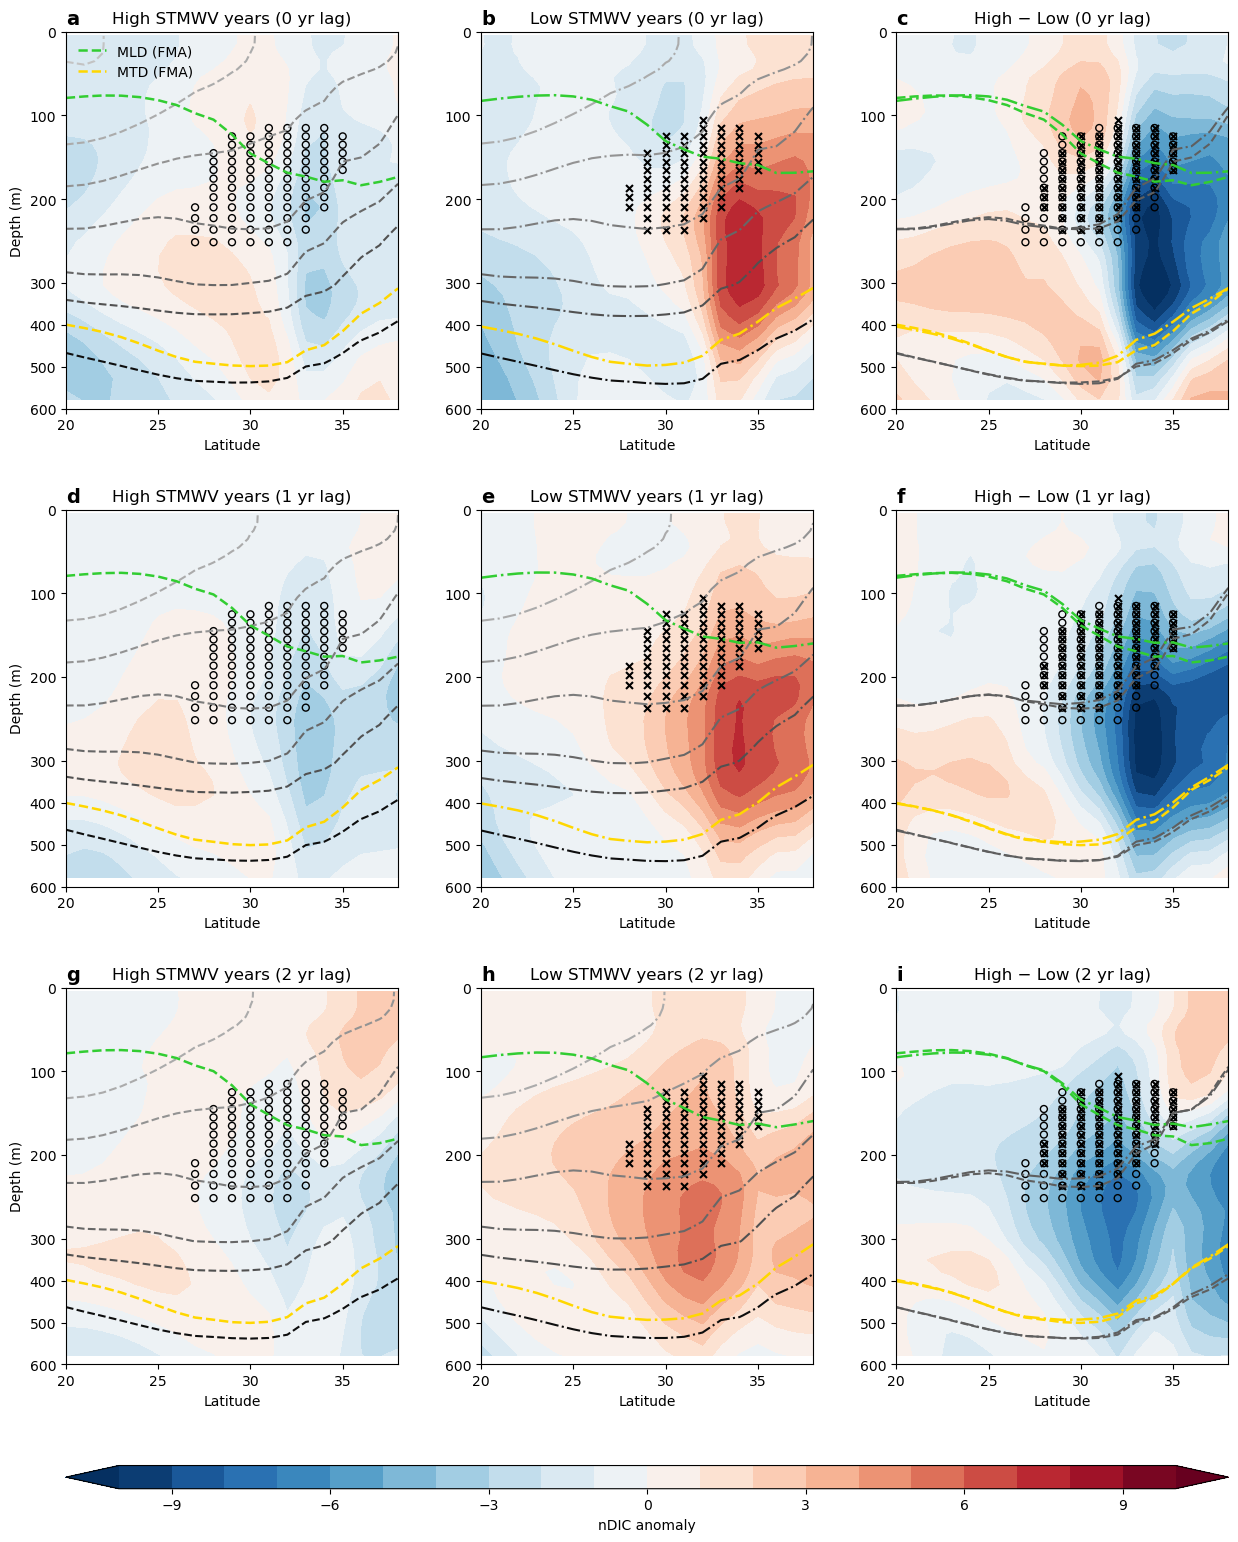

In [49]:
# ============================================================
# BLOCK 2: PLOT FROM CACHE (fast)
# - Panel (a) EXACTLY preserved
# - Panels (b–j) loaded from cache
# - Lag info added to ALL panel titles in each row
# ============================================================

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

CACHE_FILE = "/mnt/lustre/proj/kimyy/Figure_cache/cache_lag012_zonalmean_135_170.nc"
ds = xr.open_dataset(CACHE_FILE)

def depth_compress(z):
    z = np.asarray(z)
    zc = z.copy()
    mask = z > 300
    zc[mask] = 300 + (z[mask] - 300) / 2.0
    return zc

def stmw_colors(values, thr=0.5):
    cols=[]
    for v in values:
        if v>thr: cols.append("#CC79A7")
        elif v<-thr: cols.append("#009E73")
        else: cols.append("0.7")
    return cols


# ============================================================
# FIGURE LAYOUT
# ============================================================

fig = plt.figure(figsize=(15,24))
gs = fig.add_gridspec(
    5,3,
    height_ratios=[1,1.3,1.3,1.3,0.08],
    hspace=0.35,wspace=0.25
)



# ============================================================
# ---- PANELS (b–j)
# ============================================================

CONTOUR_LEVELS = [2000,2040,2080,2120,2160,2200,2300]
norm = mpl.colors.Normalize(min(CONTOUR_LEVELS), max(CONTOUR_LEVELS))
cont_colors = [mpl.cm.Greys(0.35 + 0.6*norm(lv)) for lv in CONTOUR_LEVELS]

SHADE_LEVELS = np.linspace(-10,10,21)

lags = [0,1,2]
panel_labels = [["a","b","c"],["d","e","f"],["g","h","i"]]

yticks_real = np.array([0,100,200,300,400,500,600])
yticks_comp = depth_compress(yticks_real)

lat_h = ds["lat_h"].values
z_h   = ds["z_h"].values
lat_l = ds["lat_l"].values
z_l   = ds["z_l"].values

axes_left = []

for row, lag in enumerate(lags):

    tag = f"lag{lag:02d}"
    lag_txt = f" ({lag} yr lag)"

    ndic_high = ds[f"ndic_high_{tag}"]
    ndic_low  = ds[f"ndic_low_{tag}"]

    fields = [
        ds[f"ndic_high_anom_{tag}"],
        ds[f"ndic_low_anom_{tag}"],
        ds[f"ndic_diff_{tag}"]
    ]

    mld_high = ds[f"mld_high_{tag}"]
    mld_low  = ds[f"mld_low_{tag}"]
    mtd_high = ds[f"mtd_high_{tag}"]
    mtd_low  = ds[f"mtd_low_{tag}"]

    for col in range(3):

        axc = fig.add_subplot(gs[row+1, col])

        if col == 0:
            axes_left.append(axc)

        f = fields[col]
        depth_m = f.z_t.values/100
        depth_c = depth_compress(depth_m)

        cf = axc.contourf(f.lat, depth_c, f,
                          levels=SHADE_LEVELS,
                          cmap="RdBu_r",
                          vmin=-10, vmax=10,
                          extend="both")

        if col == 0:
            axc.contour(ndic_high.lat, depth_c, ndic_high,
                        levels=CONTOUR_LEVELS,
                        colors=cont_colors,
                        linestyles="--")
            axc.set_title("High STMWV years" + lag_txt)

        elif col == 1:
            axc.contour(ndic_low.lat, depth_c, ndic_low,
                        levels=CONTOUR_LEVELS,
                        colors=cont_colors,
                        linestyles="-.")
            axc.set_title("Low STMWV years" + lag_txt)

        else:
            for data, ls in zip([ndic_high, ndic_low],["--","-."]):
                axc.contour(data.lat, depth_c, data,
                            levels=[2120,2300],
                            colors=[mpl.cm.Greys(0.7)],
                            linestyles=ls)
            axc.set_title("High − Low" + lag_txt)

        if col in [0,2]:
            axc.scatter(lat_h, depth_compress(z_h),
                        s=25, facecolors="none", edgecolors="k")
        if col in [1,2]:
            axc.scatter(lat_l, depth_compress(z_l),
                        s=25, c="k", marker="x")

        if col == 0:
            axc.plot(mld_high.lat, depth_compress(mld_high),
                     color="limegreen", lw=1.8, ls="--")
            axc.plot(mtd_high.lat, depth_compress(mtd_high),
                     color="gold", lw=1.8, ls="--")
        elif col == 1:
            axc.plot(mld_low.lat, depth_compress(mld_low),
                     color="limegreen", lw=1.8, ls="-.")
            axc.plot(mtd_low.lat, depth_compress(mtd_low),
                     color="gold", lw=1.8, ls="-.")
        else:
            axc.plot(mld_high.lat, depth_compress(mld_high),
                     color="limegreen", lw=1.8, ls="--")
            axc.plot(mld_low.lat, depth_compress(mld_low),
                     color="limegreen", lw=1.8, ls="-.")
            axc.plot(mtd_high.lat, depth_compress(mtd_high),
                     color="gold", lw=1.8, ls="--")
            axc.plot(mtd_low.lat, depth_compress(mtd_low),
                     color="gold", lw=1.8, ls="-.")

        axc.set_yticks(yticks_comp)
        axc.set_yticklabels([str(int(y)) for y in yticks_real])
        axc.set_ylim(depth_compress(600), depth_compress(0))

        if col==0:
            axc.set_ylabel("Depth (m)")
        axc.set_xlabel("Latitude")

        axc.text(0,1.02,panel_labels[row][col],
                 transform=axc.transAxes,
                 fontsize=14,fontweight="bold")

line_mld = Line2D([0],[0],color="limegreen",lw=1.8,ls="--",label="MLD (FMA)")
line_mtd = Line2D([0],[0],color="gold",lw=1.8,ls="--",label="MTD (FMA)")
axes_left[0].legend(handles=[line_mld,line_mtd],
                    loc="upper left",frameon=False)

cax = fig.add_subplot(gs[4,:])
cb = fig.colorbar(cf,cax=cax,orientation="horizontal")
cb.set_label("nDIC anomaly")

plt.savefig(
    "/mnt/lustre/proj/kimyy/Figure/LIM/AGU_DIC_ASSM/Figure_5_zonalmean_lag.pdf",
    bbox_inches="tight"
)

plt.show()

In [47]:
# ============================================================
# BLOCK 1: BUILD & SAVE CACHE (WDA version)
# - MLD/MTD composites are lagged
# - STMW markers are 0-lag reference
# - WDA data used
# ============================================================

import numpy as np
import xarray as xr

# ---------------- settings ----------------
LON_SL = slice(135, 170)
LAT_SL = slice(20, 38)
Z_SL   = slice(0, 60000)

THR = 0.5
STMW_THRESH = 0.8
LAGS = (0, 1, 2)

CLIM_Y0 = 1990
CLIM_Y1 = 2020

CACHE_FILE = "/mnt/lustre/proj/kimyy/Figure_cache/cache_lag012_zonalmean_135_170_WDA.nc"


# ============================================================
# ---------------- helpers ----------------
# ============================================================

def select_mean_lon(da, lon_sl, lat_sl, z_sl=None):
    ens_dim = next((d for d in da.dims if d.startswith("ens")), None)
    if ens_dim:
        da = da.mean(ens_dim)

    indexers = {}
    if "lon" in da.coords:
        indexers["lon"] = lon_sl
    if "lat" in da.coords:
        indexers["lat"] = lat_sl
    if z_sl is not None and "z_t" in da.coords:
        indexers["z_t"] = z_sl

    da = da.sel(**indexers)

    if "lon" in da.dims:
        da = da.mean("lon")

    return da.load()


def annual_mean(da, months=None):
    if months is not None:
        da = da.where(da.time.dt.month.isin(months), drop=True)

    ann = da.groupby("time.year").mean("time")
    ann = ann.rename({"year": "time"})
    ann["time"] = np.array(
        [np.datetime64(f"{int(y)}-07-01") for y in ann.time.values]
    )
    return ann


# ============================================================
# ---------------- high/low years (unchanged logic)
# ============================================================

STMW_raw = STMV.PD7_STMWV
STMW_index = (STMW_raw - STMW_raw.mean("time")) / STMW_raw.std("time")
STMW_index_ann = STMW_index.resample(time="YS").mean()

stmw_obs = STMW_index_ann.sel(time=slice(T0_OBS, T1))
years = stmw_obs.time.dt.year.values.astype(int)
vals  = stmw_obs.values

high_sel = years[vals >  THR]
low_sel  = years[vals < -THR]


# ============================================================
# ---------------- base fields (WDA)
# ============================================================

ndic = select_mean_lon(results["nDIC"].WDA_ds_rgd["nDIC"],
                       LON_SL, LAT_SL, Z_SL)





ndic_ann = annual_mean(ndic)

clim_mask = ((ndic_ann.time.dt.year >= CLIM_Y0) &
             (ndic_ann.time.dt.year <= CLIM_Y1))
ndic_clim = ndic_ann.sel(time=clim_mask).mean("time").load()

mld_src = results["MLD"].WDA_ds_rgd
mld_src = mld_src["MLD"] if isinstance(mld_src, xr.Dataset) else mld_src
mld = select_mean_lon(mld_src, LON_SL, LAT_SL) / 100.0
mld_ann = annual_mean(mld, months=[2,3,4])

mtd_src = results["MTD"].WDA_ds_rgd
mtd_src = mtd_src["MTD"] if isinstance(mtd_src, xr.Dataset) else mtd_src
mtd = select_mean_lon(mtd_src, LON_SL, LAT_SL) / 100.0
mtd_ann = annual_mean(mtd, months=[2,3,4])


# ============================================================
# ---------------- STMW markers (WDA field)
# ============================================================

stmw_field = (
    WDA_STMWW_rgd
    .sel(lon=LON_SL, lat=LAT_SL, z_t=Z_SL)
    .mean("lon")
    .load()
)

years_cf = np.array([t.year for t in stmw_field.time.values], dtype=int)
year_coord = xr.DataArray(years_cf, dims="time")

stmw_frac = ((stmw_field > 0)
             .groupby(year_coord)
             .mean("time")
             .rename({"group":"year"}))

high_exist = np.intersect1d(high_sel, stmw_frac.year.values)
low_exist  = np.intersect1d(low_sel,  stmw_frac.year.values)

stmw_high = stmw_frac.sel(year=high_exist).mean("year") >= STMW_THRESH
stmw_low  = stmw_frac.sel(year=low_exist).mean("year")  >= STMW_THRESH

z_h_idx, lat_h_idx = np.where(stmw_high.values)
z_l_idx, lat_l_idx = np.where(stmw_low.values)

lat_h = stmw_high.lat.values[lat_h_idx]
z_h   = stmw_high.z_t.values[z_h_idx] / 100.0
lat_l = stmw_low.lat.values[lat_l_idx]
z_l   = stmw_low.z_t.values[z_l_idx] / 100.0


# ============================================================
# ---------------- lag composites
# ============================================================

ds_out = xr.Dataset()
ds_out["ndic_clim"] = ndic_clim

ds_out = ds_out.assign_coords(
    lat_h=("pt_h", lat_h),
    z_h=("pt_h", z_h),
    lat_l=("pt_l", lat_l),
    z_l=("pt_l", z_l),
)

all_years = ndic_ann.time.dt.year.values.astype(int)

for lag in LAGS:

    high_lag = high_sel + lag
    low_lag  = low_sel  + lag

    ndic_high = ndic_ann.sel(
        time=np.isin(all_years, high_lag)
    ).mean("time").load()

    ndic_low = ndic_ann.sel(
        time=np.isin(all_years, low_lag)
    ).mean("time").load()

    ndic_high_anom = (ndic_high - ndic_clim).load()
    ndic_low_anom  = (ndic_low  - ndic_clim).load()
    ndic_diff      = (ndic_high - ndic_low).load()

    mld_high = mld_ann.sel(
        time=np.isin(mld_ann.time.dt.year.values.astype(int), high_lag)
    ).mean("time").load()

    mld_low = mld_ann.sel(
        time=np.isin(mld_ann.time.dt.year.values.astype(int), low_lag)
    ).mean("time").load()

    mtd_high = mtd_ann.sel(
        time=np.isin(mtd_ann.time.dt.year.values.astype(int), high_lag)
    ).mean("time").load()

    mtd_low = mtd_ann.sel(
        time=np.isin(mtd_ann.time.dt.year.values.astype(int), low_lag)
    ).mean("time").load()

    tag = f"lag{lag:02d}"

    ds_out[f"ndic_high_{tag}"] = ndic_high
    ds_out[f"ndic_low_{tag}"]  = ndic_low
    ds_out[f"ndic_high_anom_{tag}"] = ndic_high_anom
    ds_out[f"ndic_low_anom_{tag}"]  = ndic_low_anom
    ds_out[f"ndic_diff_{tag}"]      = ndic_diff

    ds_out[f"mld_high_{tag}"] = mld_high
    ds_out[f"mld_low_{tag}"]  = mld_low
    ds_out[f"mtd_high_{tag}"] = mtd_high
    ds_out[f"mtd_low_{tag}"]  = mtd_low


ds_out.to_netcdf(CACHE_FILE)
print("WDA cache saved:", CACHE_FILE)

WDA cache saved: /mnt/lustre/proj/kimyy/Figure_cache/cache_lag012_zonalmean_135_170_WDA.nc


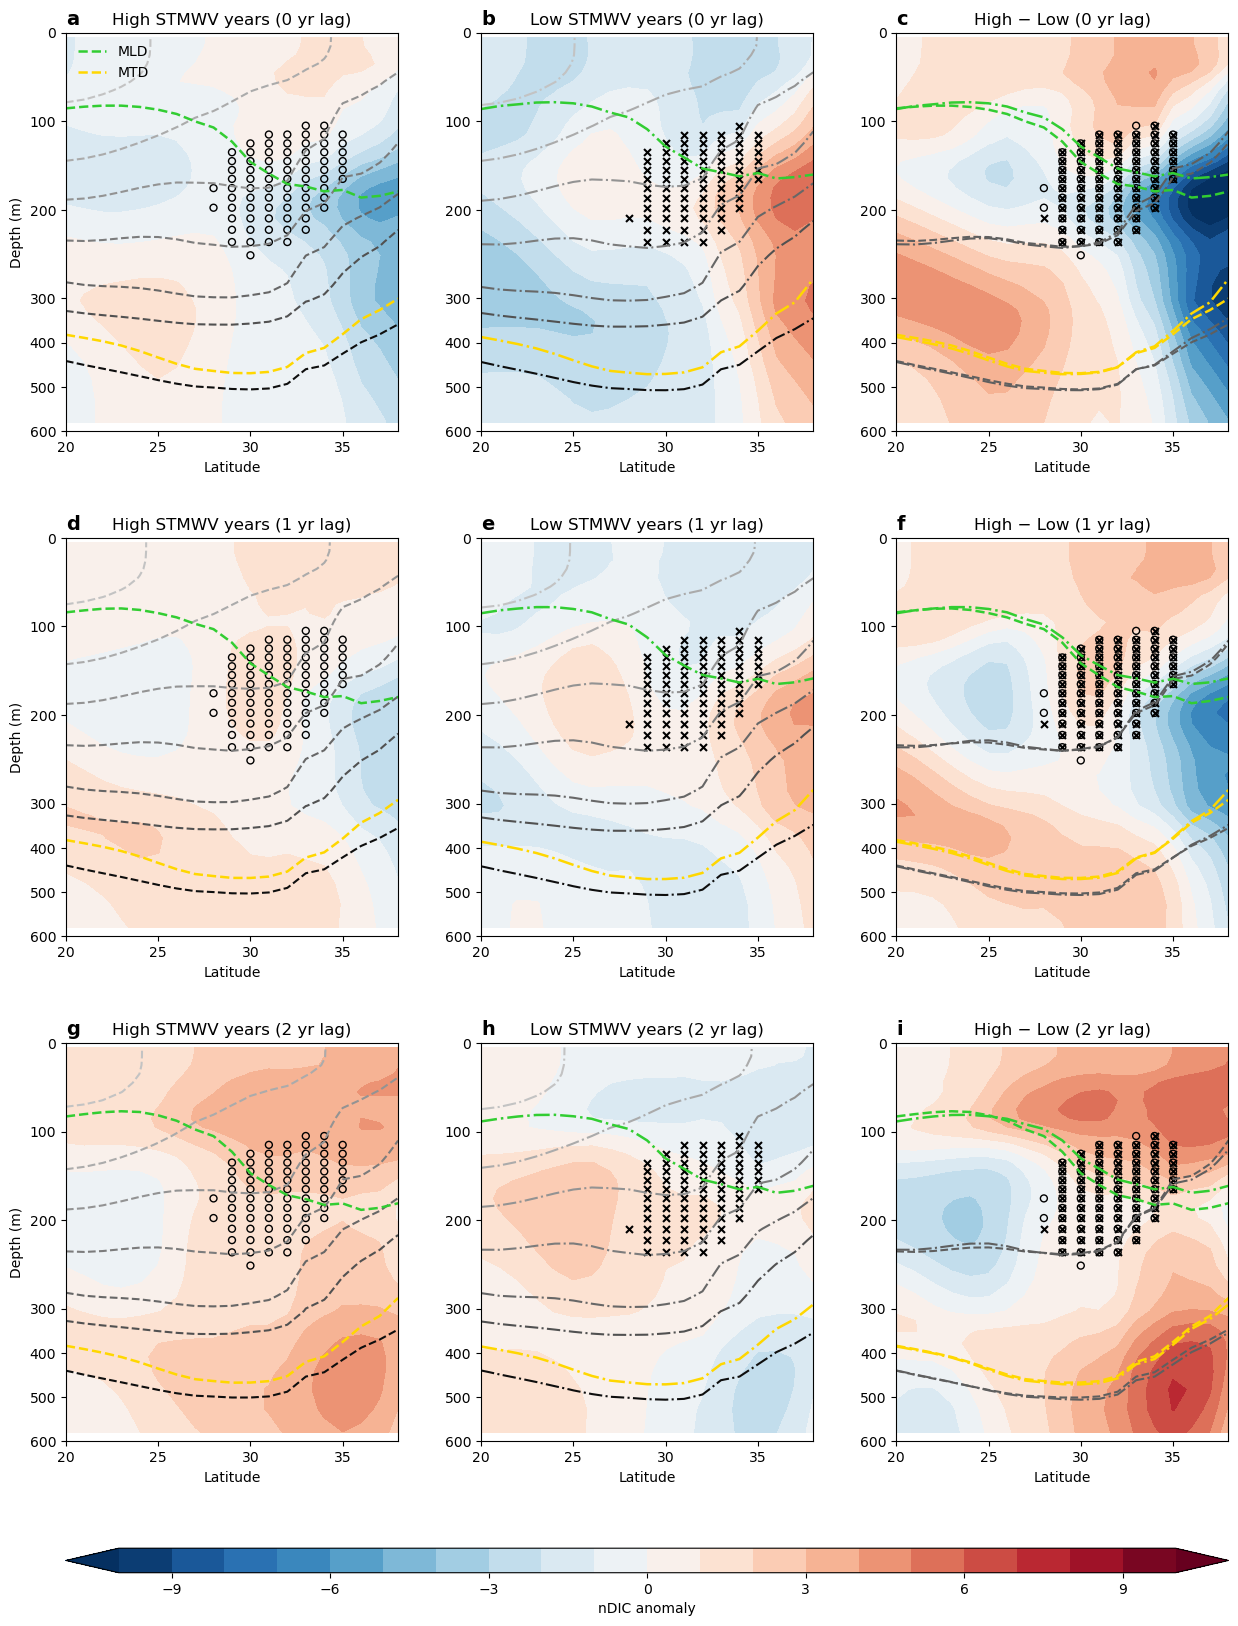

In [48]:
# ============================================================
# BLOCK 2: PLOT FROM CACHE (WDA version)
# - No panel (a)
# - Panels only (b–j structure)
# - WDA data
# ============================================================

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D



CACHE_FILE = "/mnt/lustre/proj/kimyy/Figure_cache/cache_lag012_zonalmean_135_170_WDA.nc"
ds = xr.open_dataset(CACHE_FILE)

def depth_compress(z):
    z = np.asarray(z)
    zc = z.copy()
    mask = z > 300
    zc[mask] = 300 + (z[mask] - 300) / 2.0
    return zc


# ============================================================
# FIGURE LAYOUT (3 rows × 3 cols)
# ============================================================

fig = plt.figure(figsize=(15,20))
gs = fig.add_gridspec(
    4,3,
    height_ratios=[1.3,1.3,1.3,0.08],
    hspace=0.35,wspace=0.25
)

CONTOUR_LEVELS = [2000,2040,2080,2120,2160,2200,2300]
norm = mpl.colors.Normalize(min(CONTOUR_LEVELS), max(CONTOUR_LEVELS))
cont_colors = [mpl.cm.Greys(0.35 + 0.6*norm(lv)) for lv in CONTOUR_LEVELS]

SHADE_LEVELS = np.linspace(-10,10,21)

lags = [0,1,2]
panel_labels = [["b","c","d"],["e","f","g"],["h","i","j"]]

yticks_real = np.array([0,100,200,300,400,500,600])
yticks_comp = depth_compress(yticks_real)

lat_h = ds["lat_h"].values
z_h   = ds["z_h"].values
lat_l = ds["lat_l"].values
z_l   = ds["z_l"].values

axes_left = []

panel_letter = ord("a")

for row, lag in enumerate(lags):

    tag = f"lag{lag:02d}"
    lag_txt = f" ({lag} yr lag)"

    ndic_high = ds[f"ndic_high_{tag}"]
    ndic_low  = ds[f"ndic_low_{tag}"]

    fields = [
        ds[f"ndic_high_anom_{tag}"],
        ds[f"ndic_low_anom_{tag}"],
        ds[f"ndic_diff_{tag}"]
    ]

    mld_high = ds[f"mld_high_{tag}"]
    mld_low  = ds[f"mld_low_{tag}"]
    mtd_high = ds[f"mtd_high_{tag}"]
    mtd_low  = ds[f"mtd_low_{tag}"]

    for col in range(3):

        ax = fig.add_subplot(gs[row, col])

        if col == 0:
            axes_left.append(ax)

        f = fields[col]
        depth_m = f.z_t.values/100
        depth_c = depth_compress(depth_m)

        cf = ax.contourf(
            f.lat, depth_c, f,
            levels=SHADE_LEVELS,
            cmap="RdBu_r",
            vmin=-10, vmax=10,
            extend="both"
        )

        if col == 0:
            ax.contour(ndic_high.lat, depth_c, ndic_high,
                       levels=CONTOUR_LEVELS,
                       colors=cont_colors,
                       linestyles="--")
            ax.set_title("High STMWV years" + lag_txt)

        elif col == 1:
            ax.contour(ndic_low.lat, depth_c, ndic_low,
                       levels=CONTOUR_LEVELS,
                       colors=cont_colors,
                       linestyles="-.")
            ax.set_title("Low STMWV years" + lag_txt)

        else:
            for data, ls in zip([ndic_high, ndic_low],["--","-."]):
                ax.contour(data.lat, depth_c, data,
                           levels=[2120,2300],
                           colors=[mpl.cm.Greys(0.7)],
                           linestyles=ls)
            ax.set_title("High − Low" + lag_txt)

        if col in [0,2]:
            ax.scatter(lat_h, depth_compress(z_h),
                       s=25, facecolors="none", edgecolors="k")
        if col in [1,2]:
            ax.scatter(lat_l, depth_compress(z_l),
                       s=25, c="k", marker="x")

        if col == 0:
            ax.plot(mld_high.lat, depth_compress(mld_high),
                    color="limegreen", lw=1.8, ls="--")
            ax.plot(mtd_high.lat, depth_compress(mtd_high),
                    color="gold", lw=1.8, ls="--")
        elif col == 1:
            ax.plot(mld_low.lat, depth_compress(mld_low),
                    color="limegreen", lw=1.8, ls="-.")
            ax.plot(mtd_low.lat, depth_compress(mtd_low),
                    color="gold", lw=1.8, ls="-.")
        else:
            ax.plot(mld_high.lat, depth_compress(mld_high),
                    color="limegreen", lw=1.8, ls="--")
            ax.plot(mld_low.lat, depth_compress(mld_low),
                    color="limegreen", lw=1.8, ls="-.")
            ax.plot(mtd_high.lat, depth_compress(mtd_high),
                    color="gold", lw=1.8, ls="--")
            ax.plot(mtd_low.lat, depth_compress(mtd_low),
                    color="gold", lw=1.8, ls="-.")

        ax.set_yticks(yticks_comp)
        ax.set_yticklabels([str(int(y)) for y in yticks_real])
        ax.set_ylim(depth_compress(600), depth_compress(0))
        ax.set_xlim(f.lat.min().item(), 38) # til 38N
        
        if col == 0:
            ax.set_ylabel("Depth (m)")
        ax.set_xlabel("Latitude")

        ax.text(0,1.02,chr(panel_letter),
                transform=ax.transAxes,
                fontsize=14,fontweight="bold")
        panel_letter += 1


line_mld = Line2D([0],[0],color="limegreen",lw=1.8,ls="--",label="MLD")
line_mtd = Line2D([0],[0],color="gold",lw=1.8,ls="--",label="MTD")
axes_left[0].legend(handles=[line_mld,line_mtd],
                    loc="upper left",frameon=False)

cax = fig.add_subplot(gs[3,:])
cb = fig.colorbar(cf,cax=cax,orientation="horizontal")
cb.set_label("nDIC anomaly")

plt.savefig(
    "/mnt/lustre/proj/kimyy/Figure/LIM/AGU_DIC_ASSM/Figure_5_zonalmean_lag_WDA.pdf",
    bbox_inches="tight"
)

plt.show()